In [1]:
from glob import glob
from analysis_utlis import *
from other_utlis import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### P_app prediction with Hybrid LGFE profiles

#### 1. FCNN

#### 1. A. Is there a better FCNN architecture? 

TLDR : Not really, the archs under this study are not significantly different in performance (using non-parameteric testing) - irrespective of what kind of data spliting strategy used

In [2]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol_halogen.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN/evaluation_pampa.csv"],
                  ["../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN/evaluation_bbb.csv"]]


/home/ashj/projects/permeation-project/ml_analysis/analysis_utlis.py:326: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


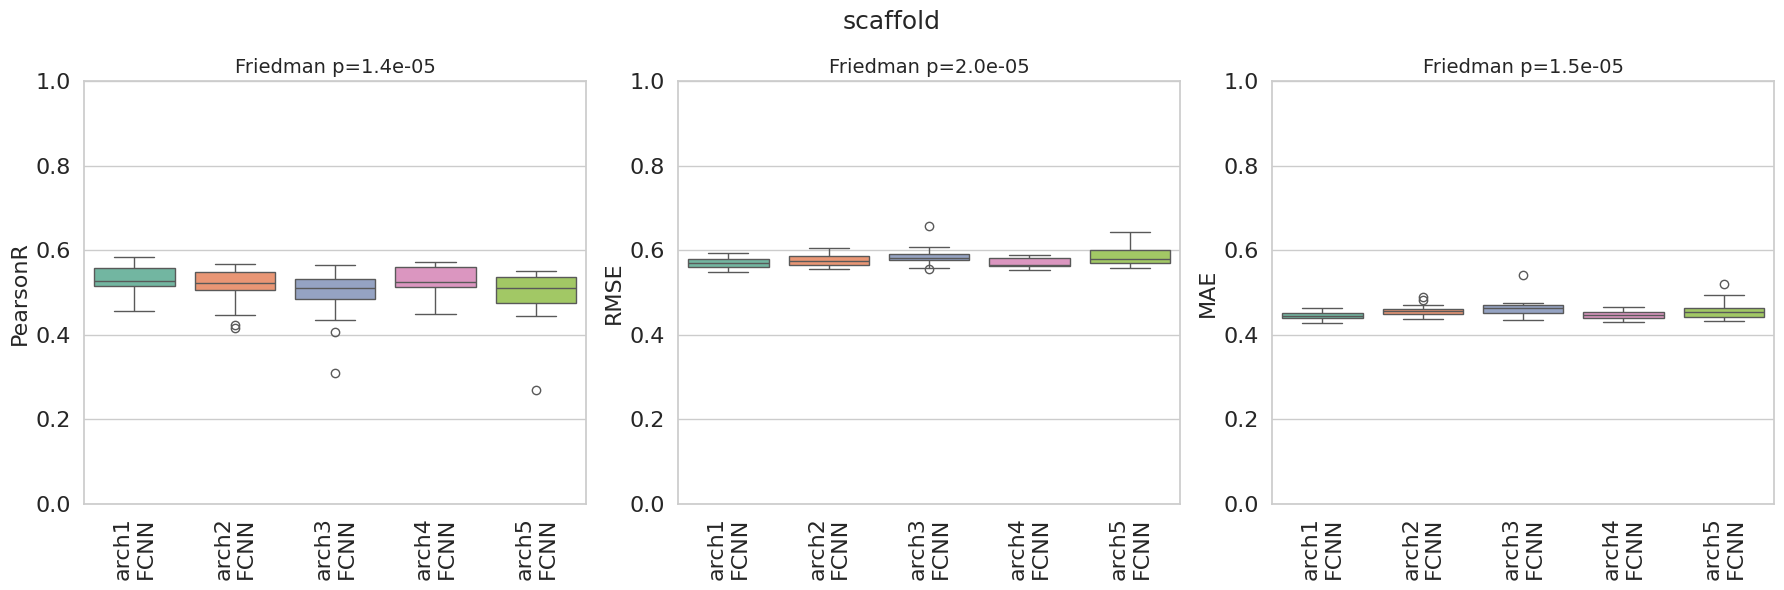

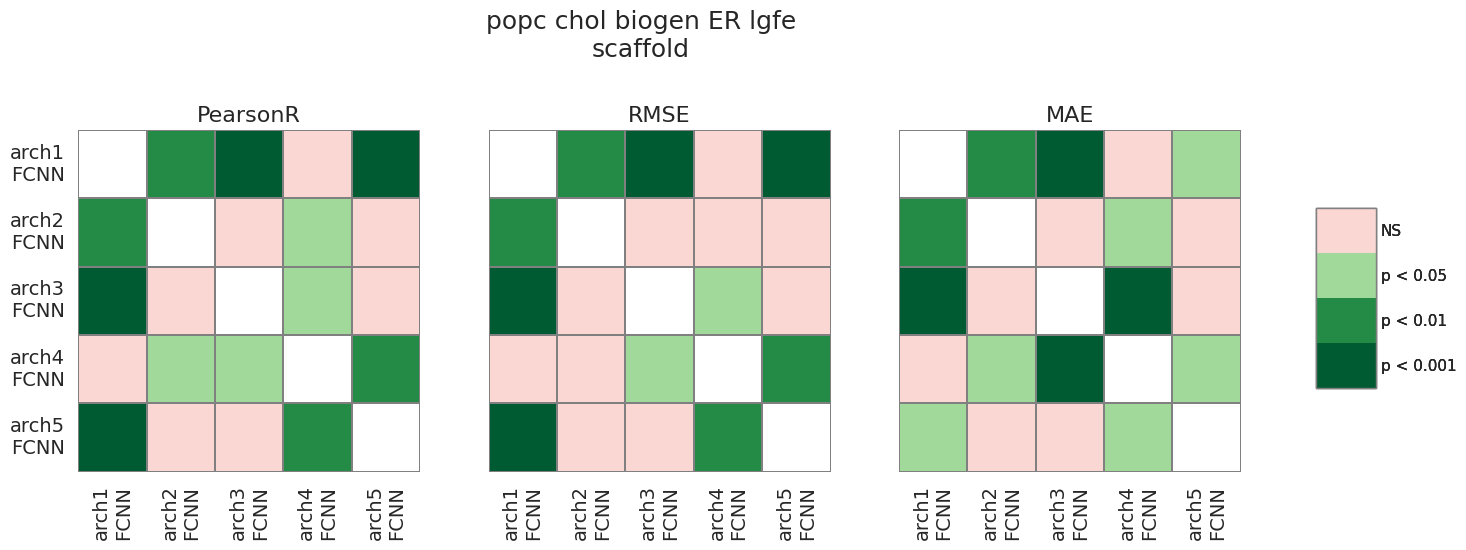

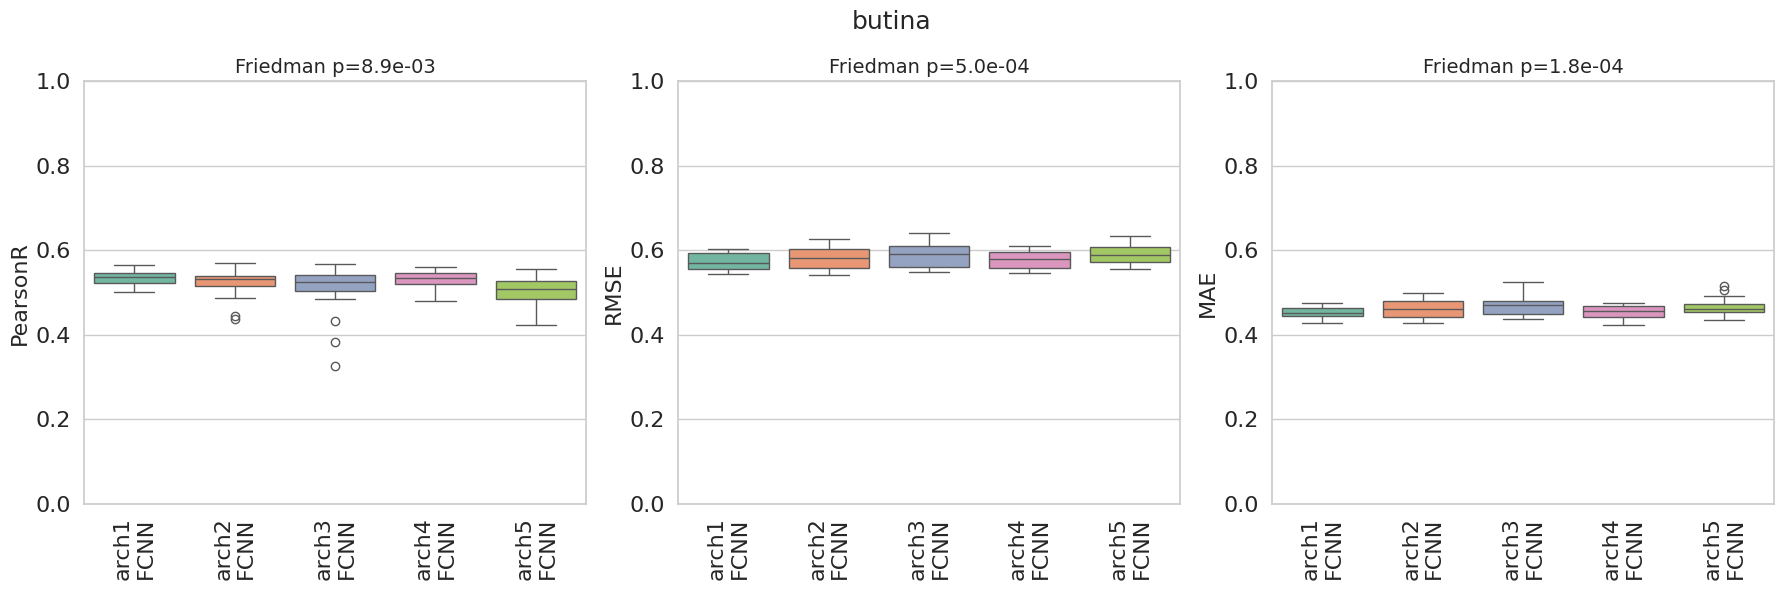

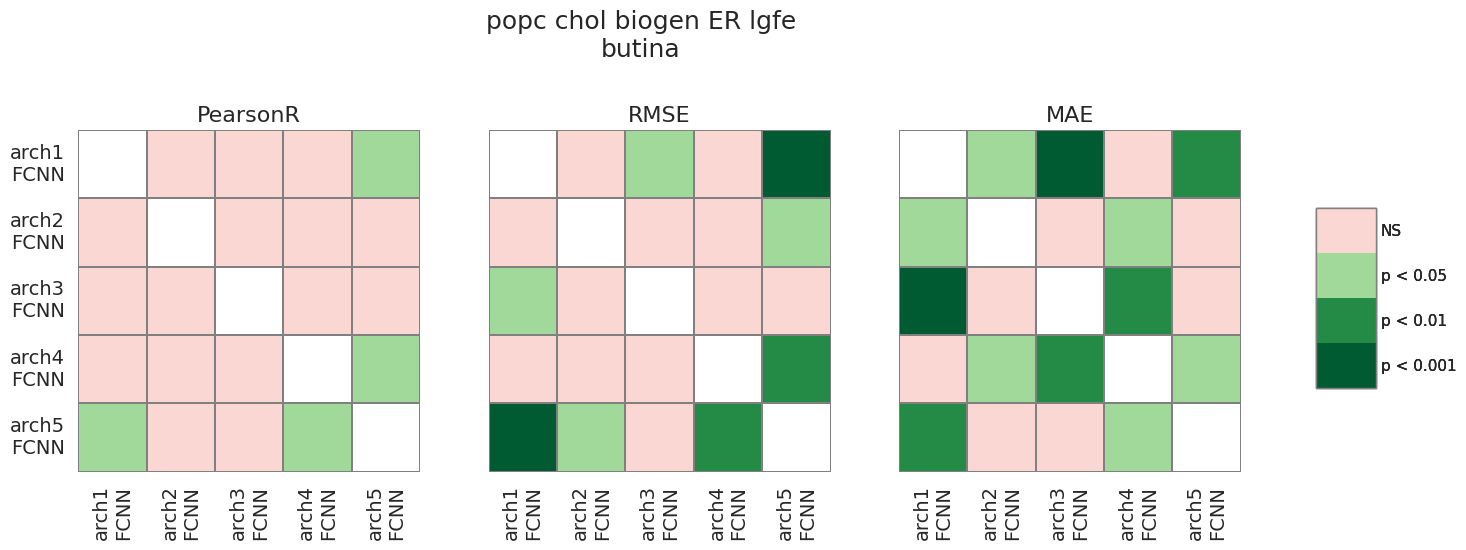

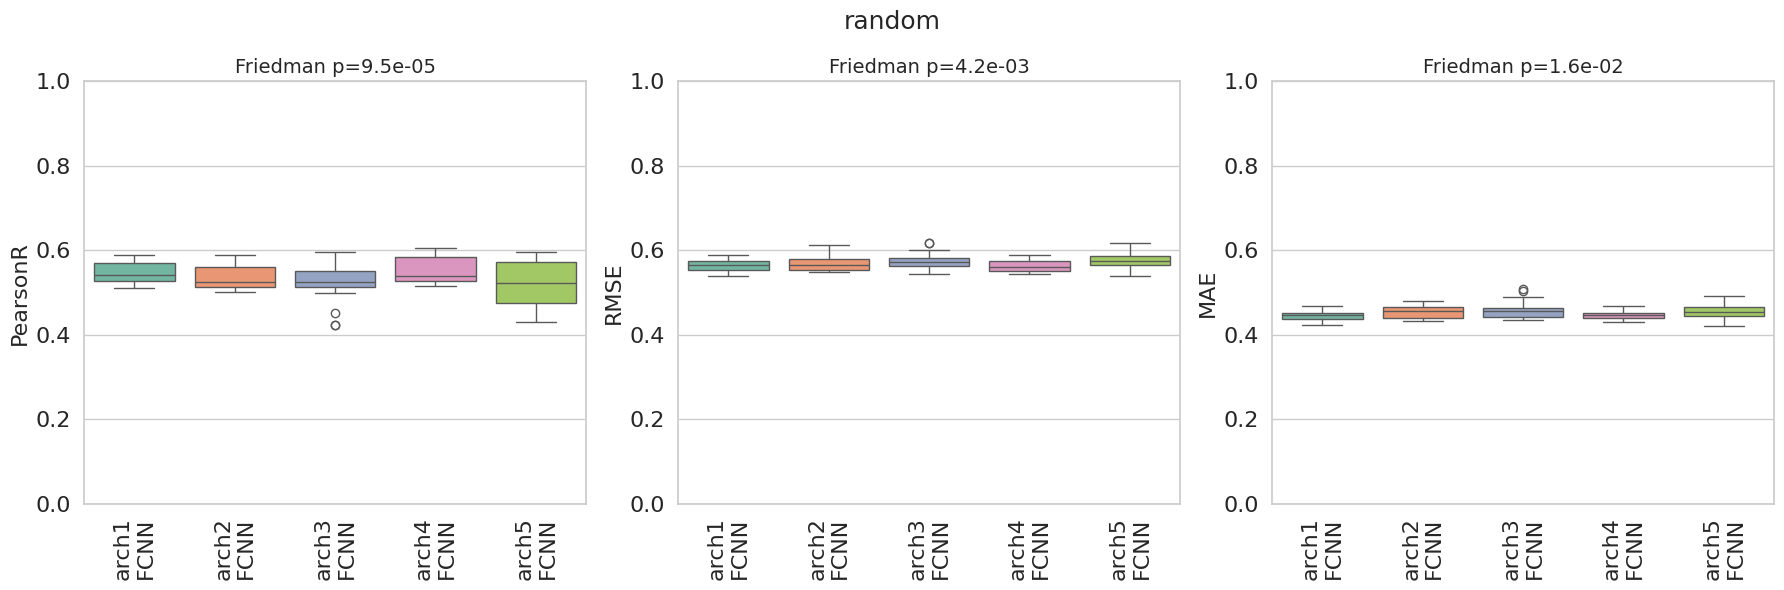

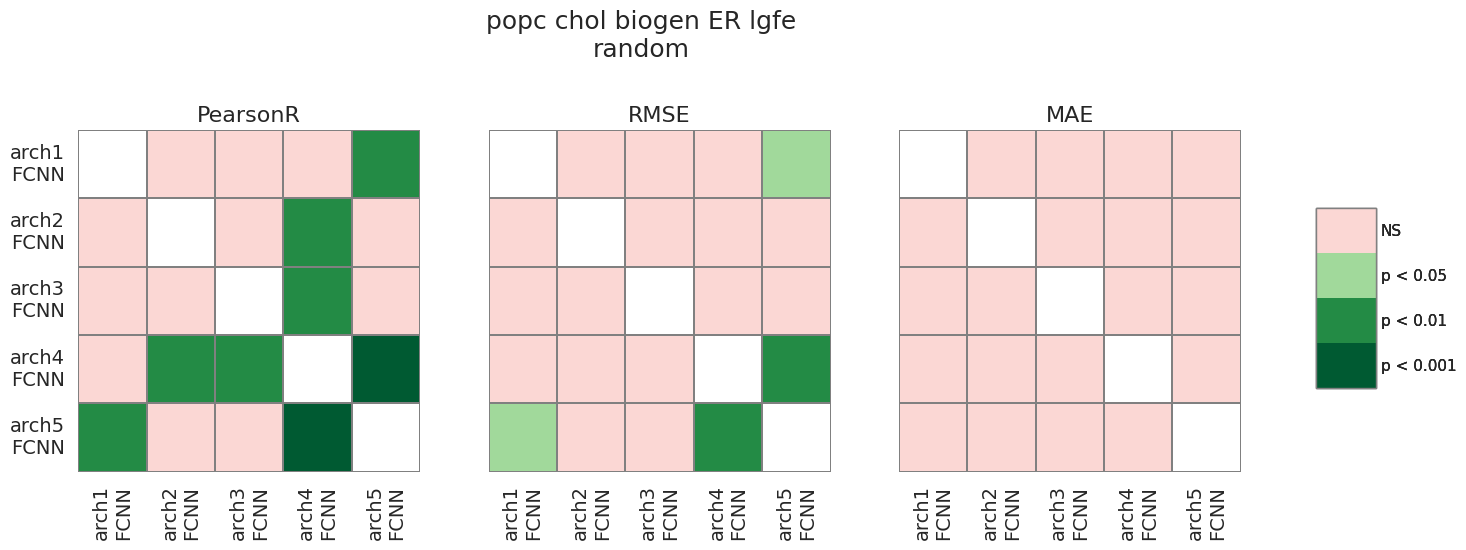

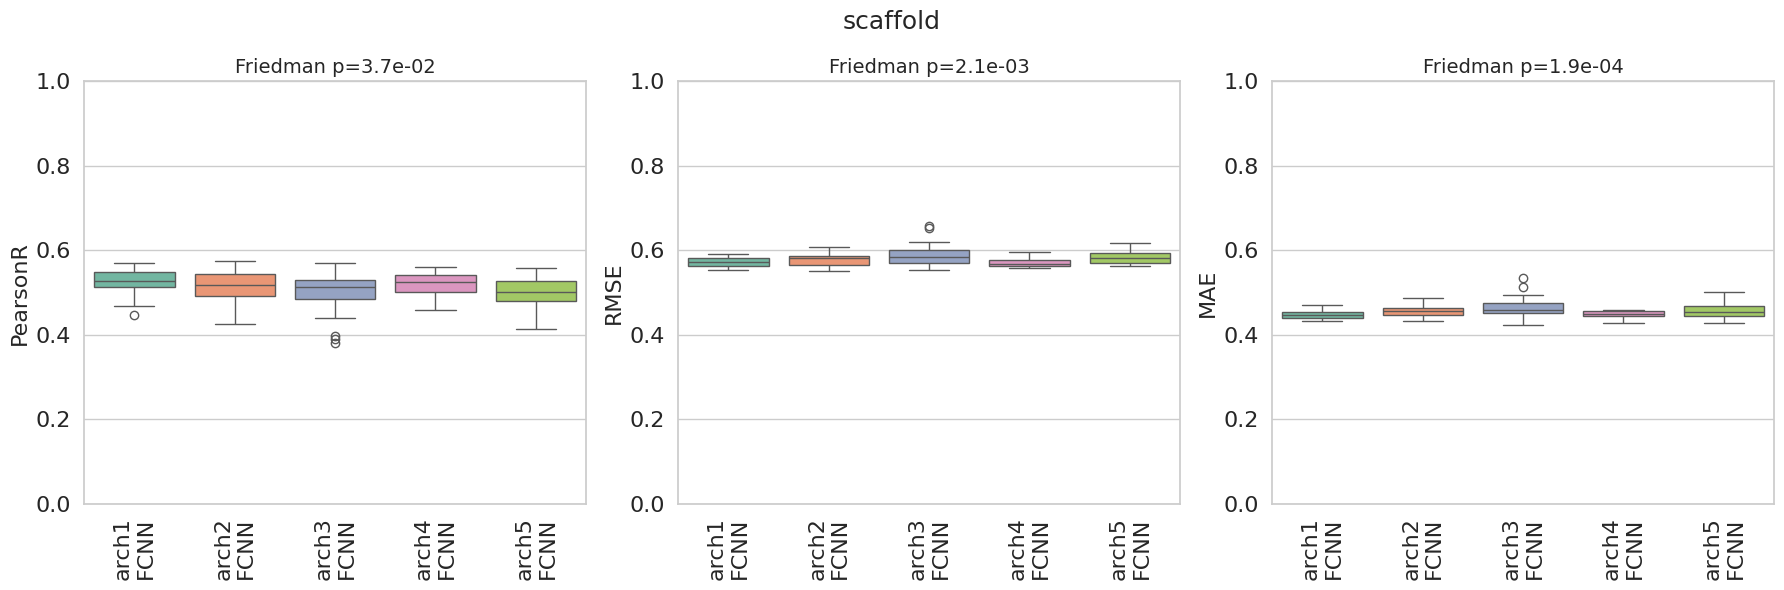

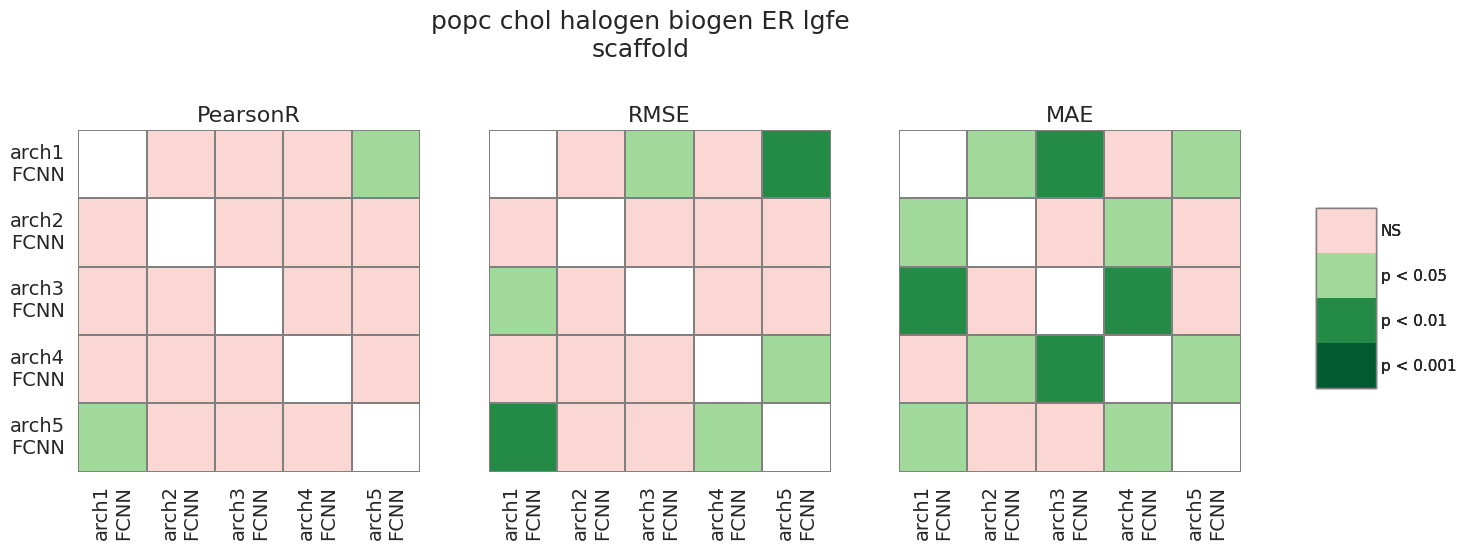

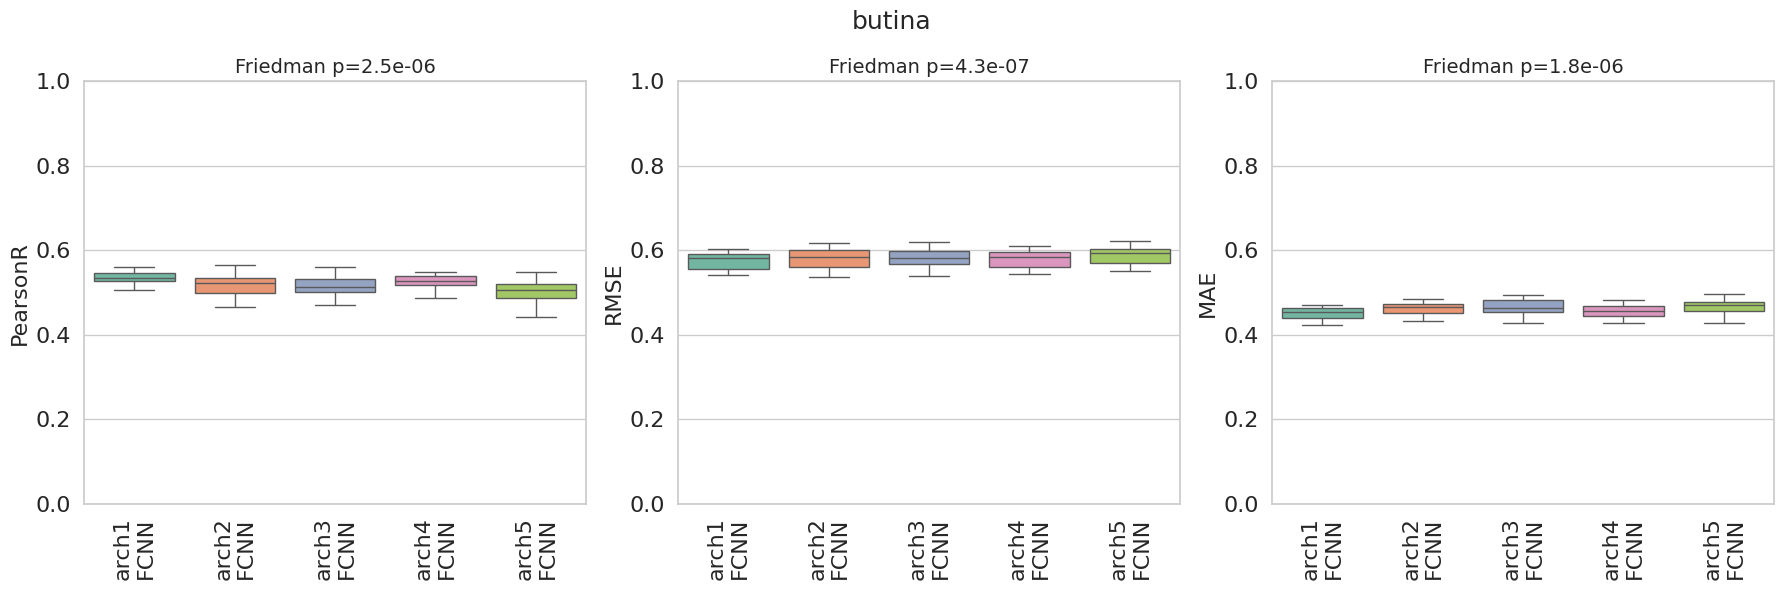

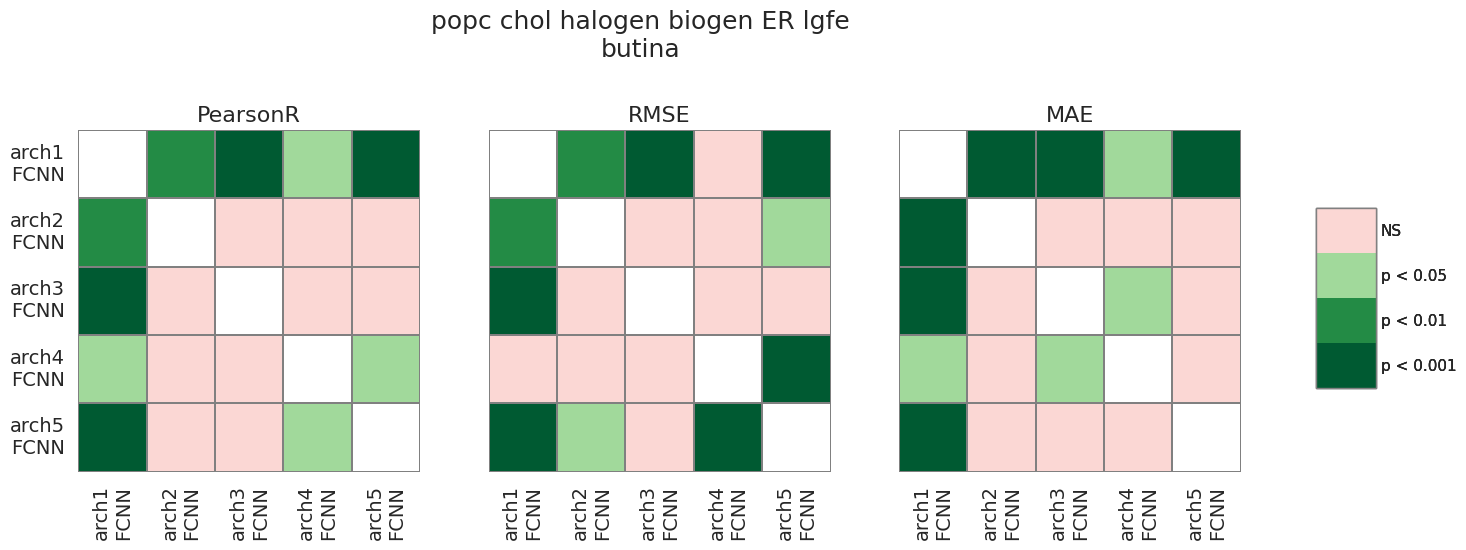

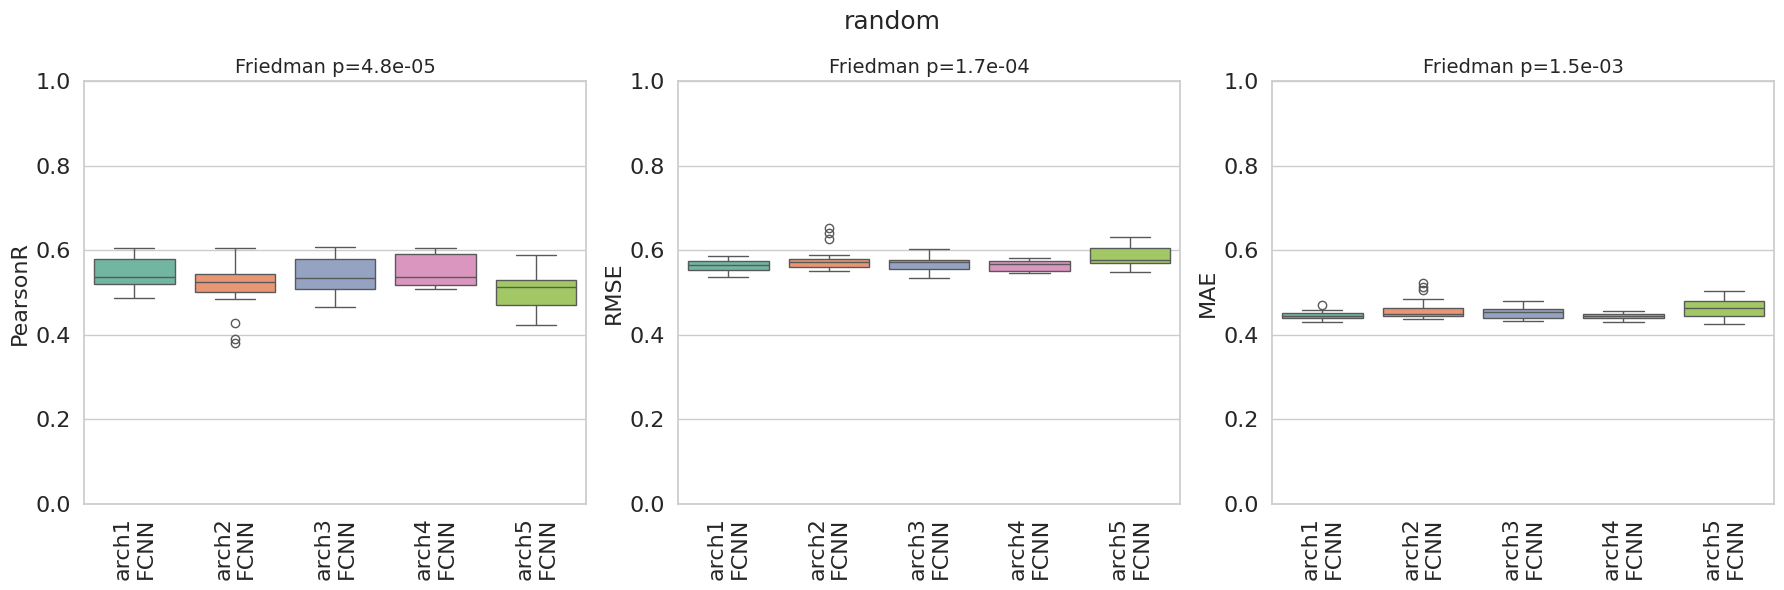

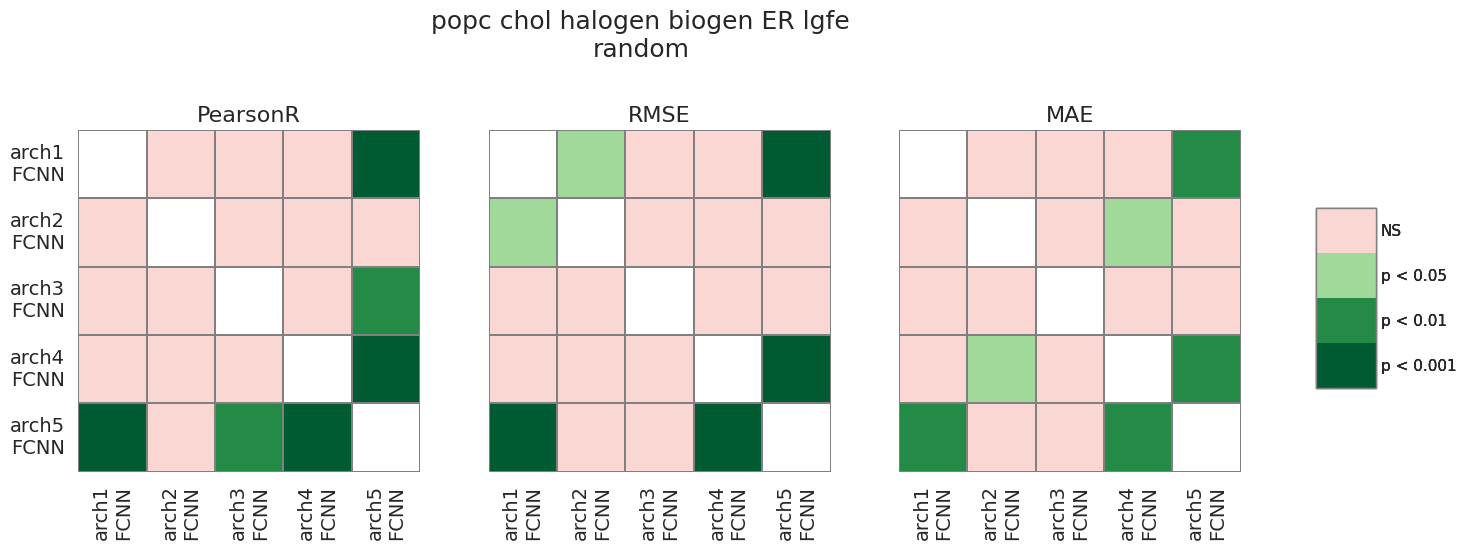

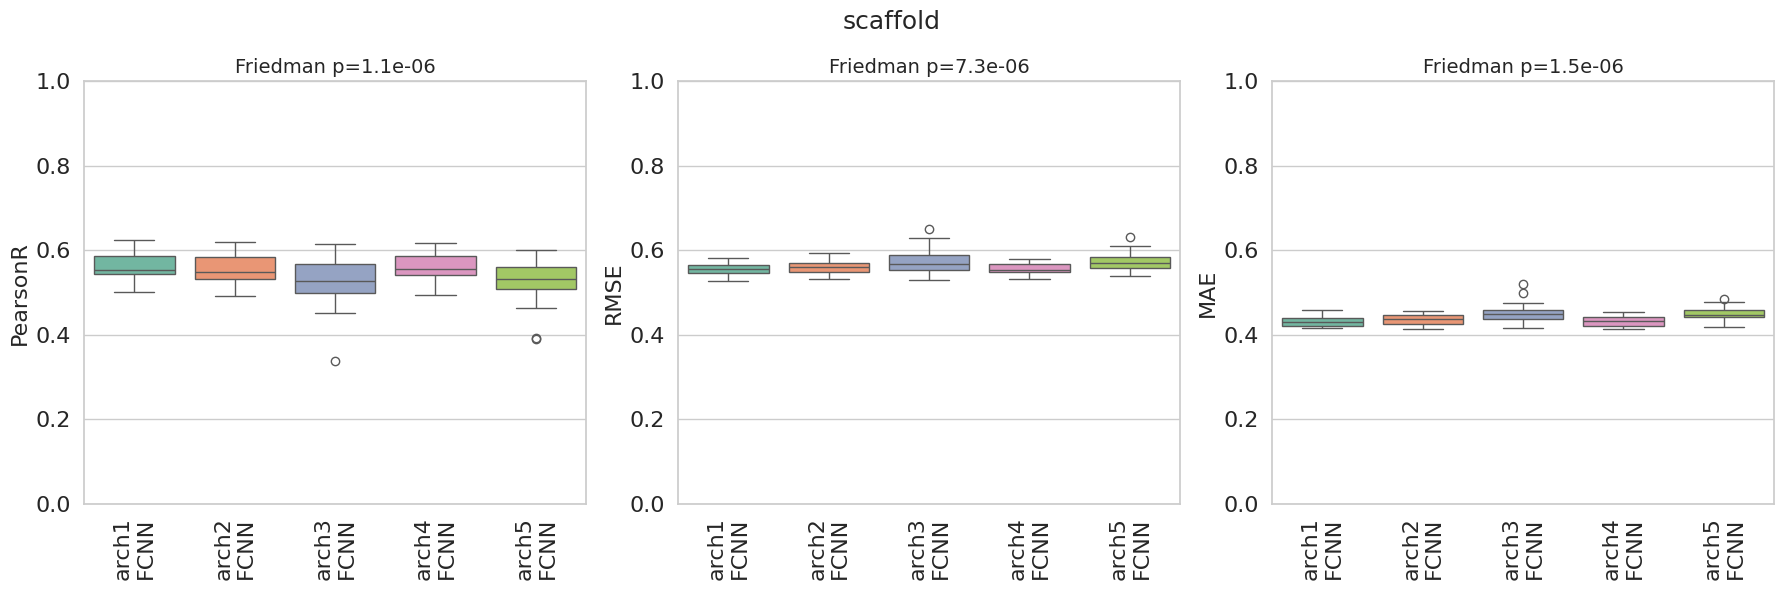

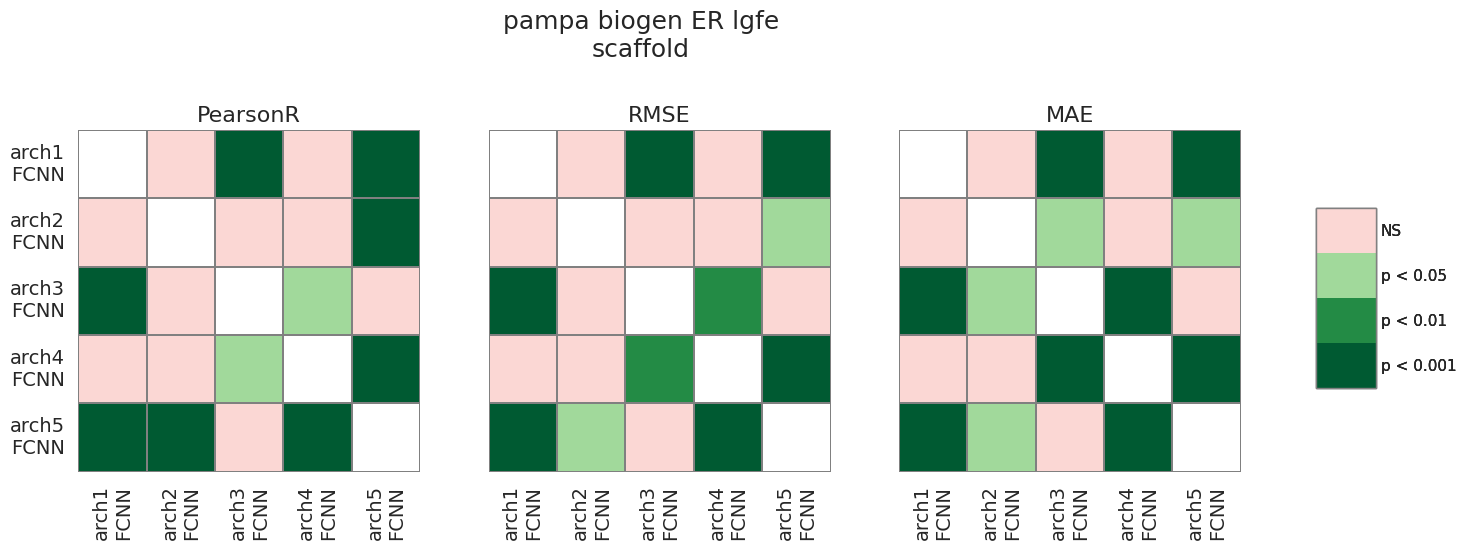

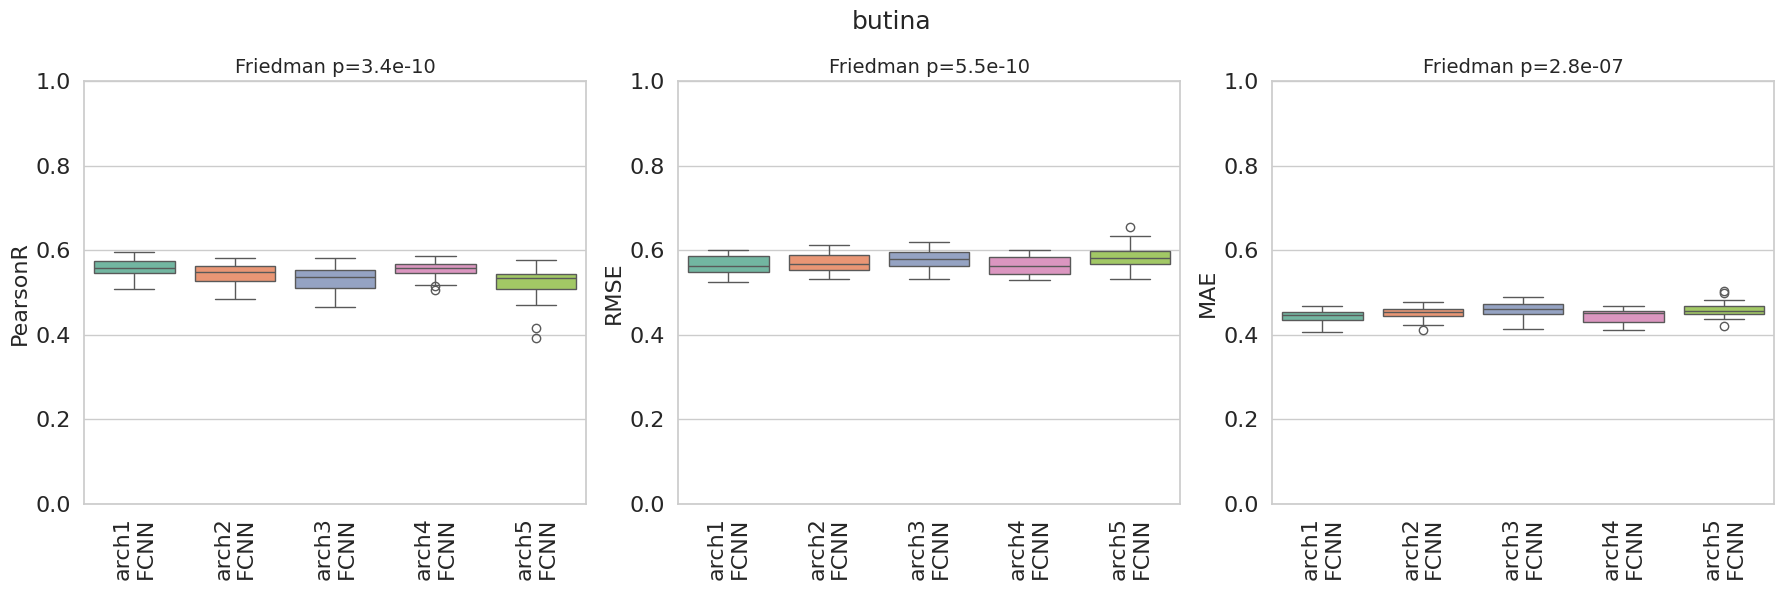

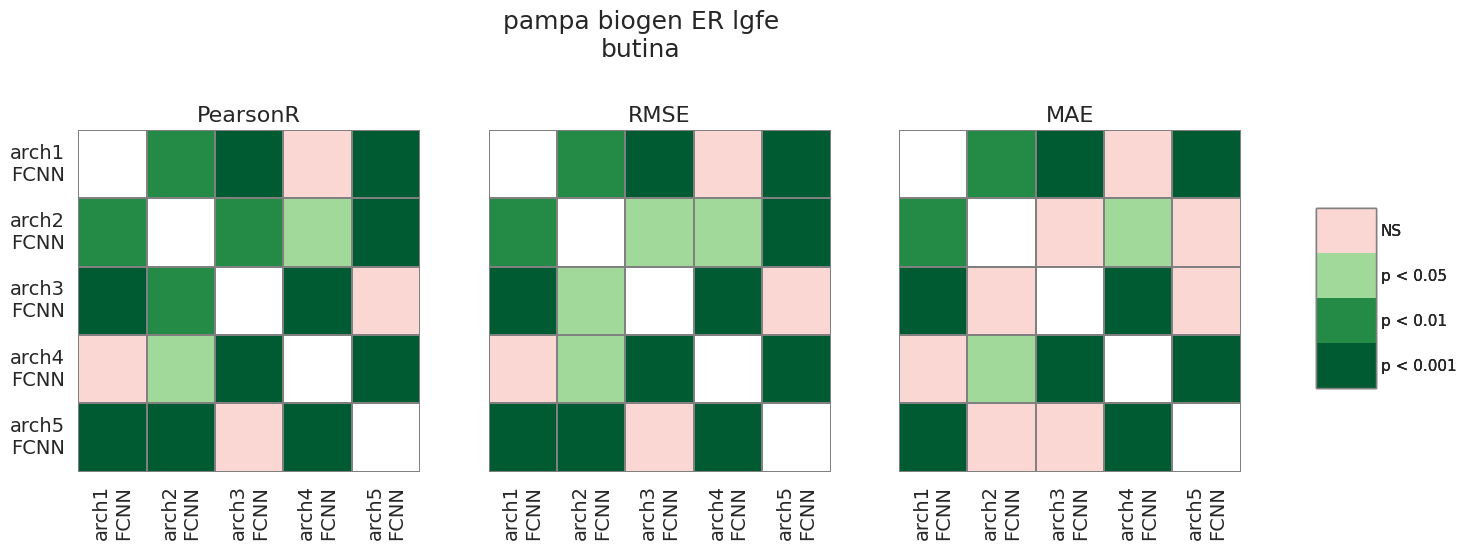

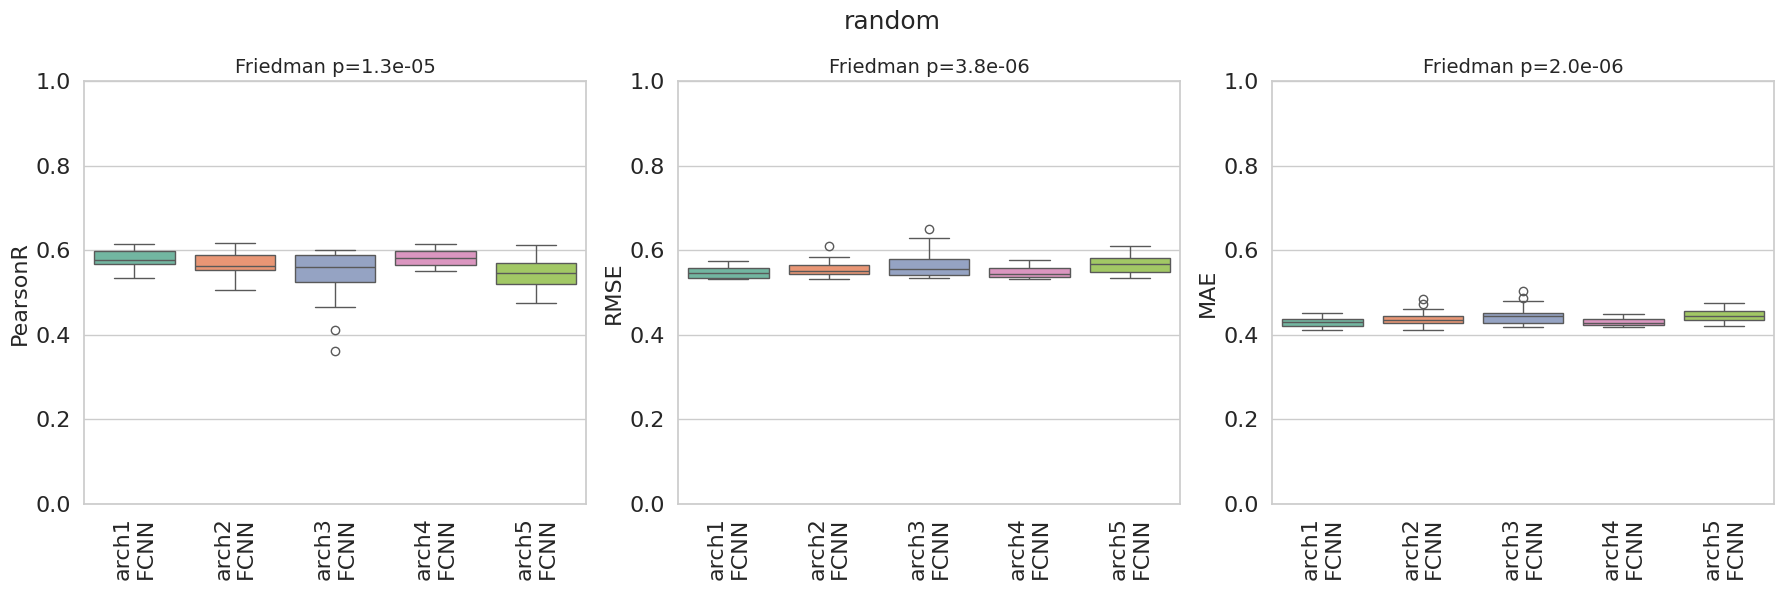

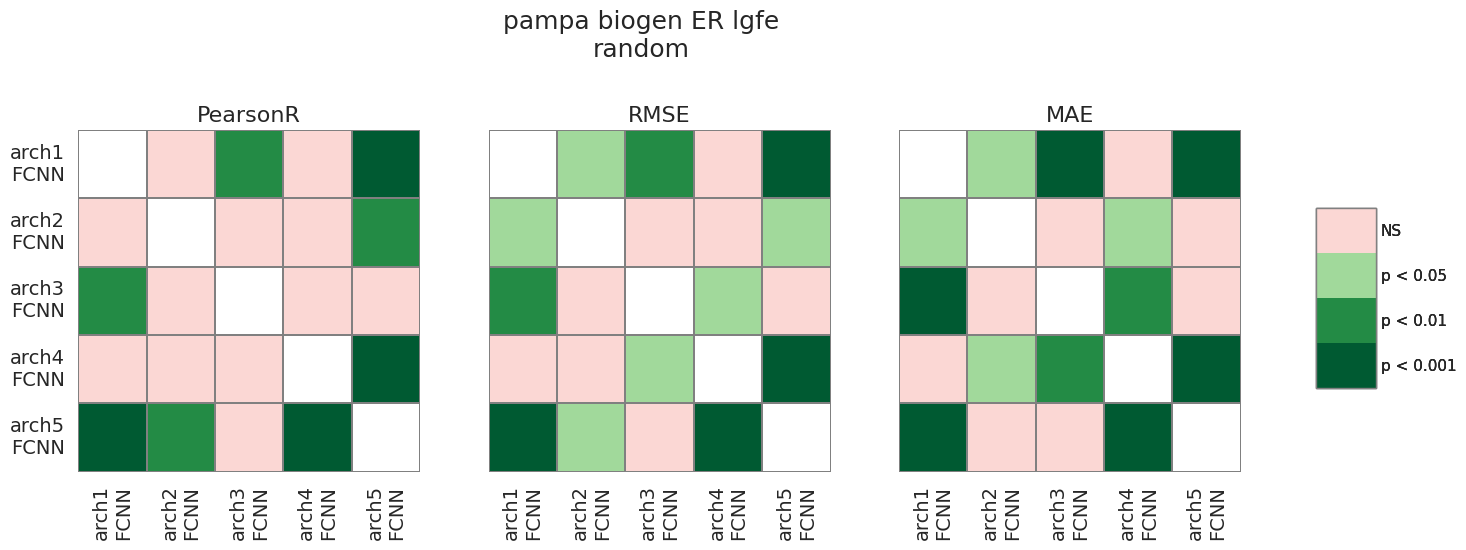

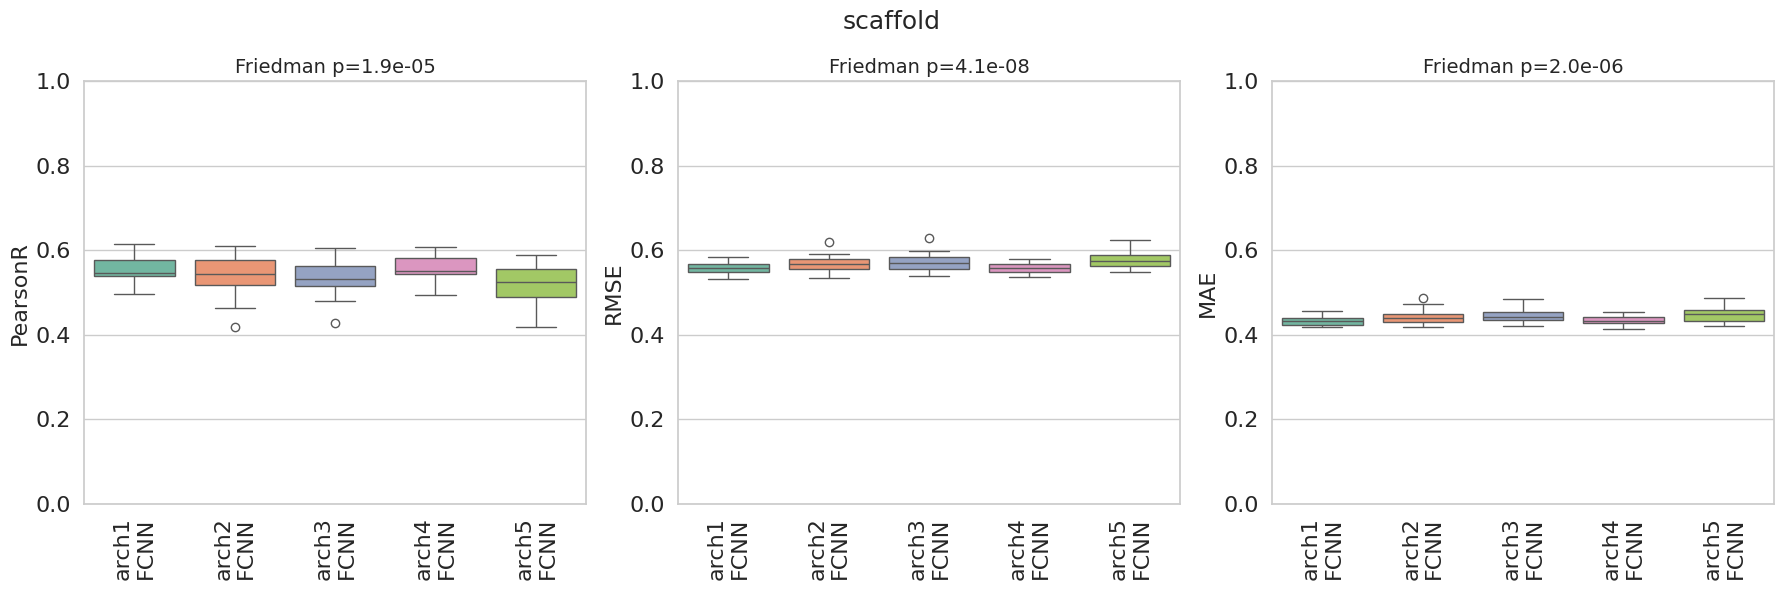

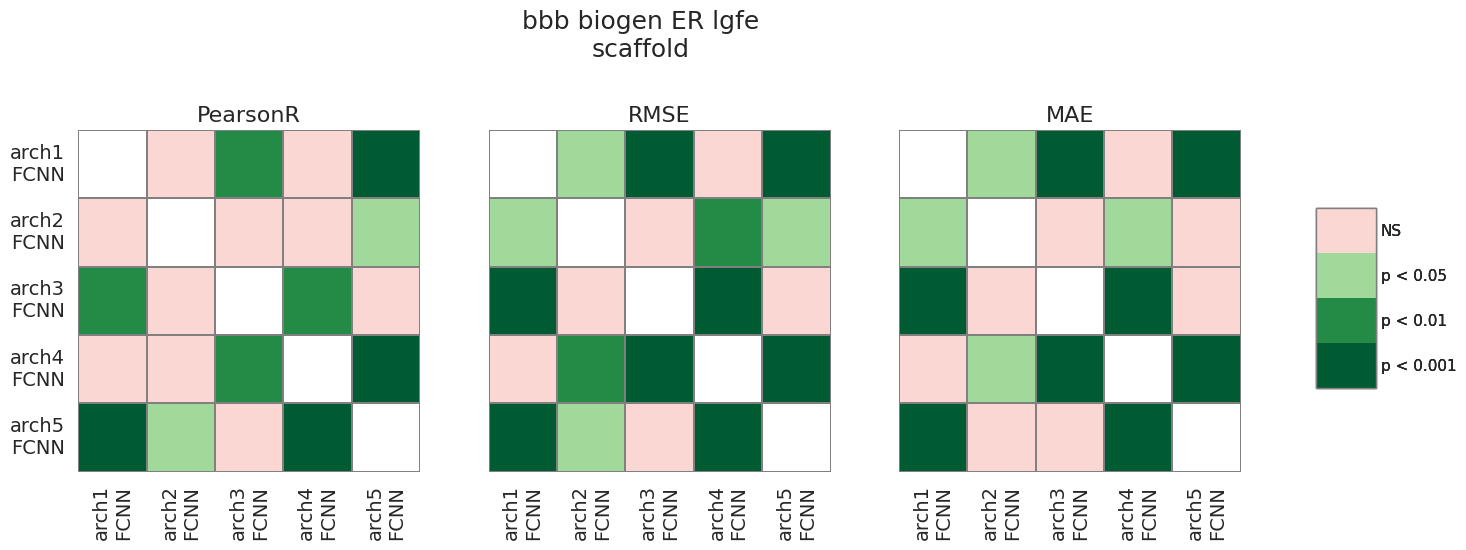

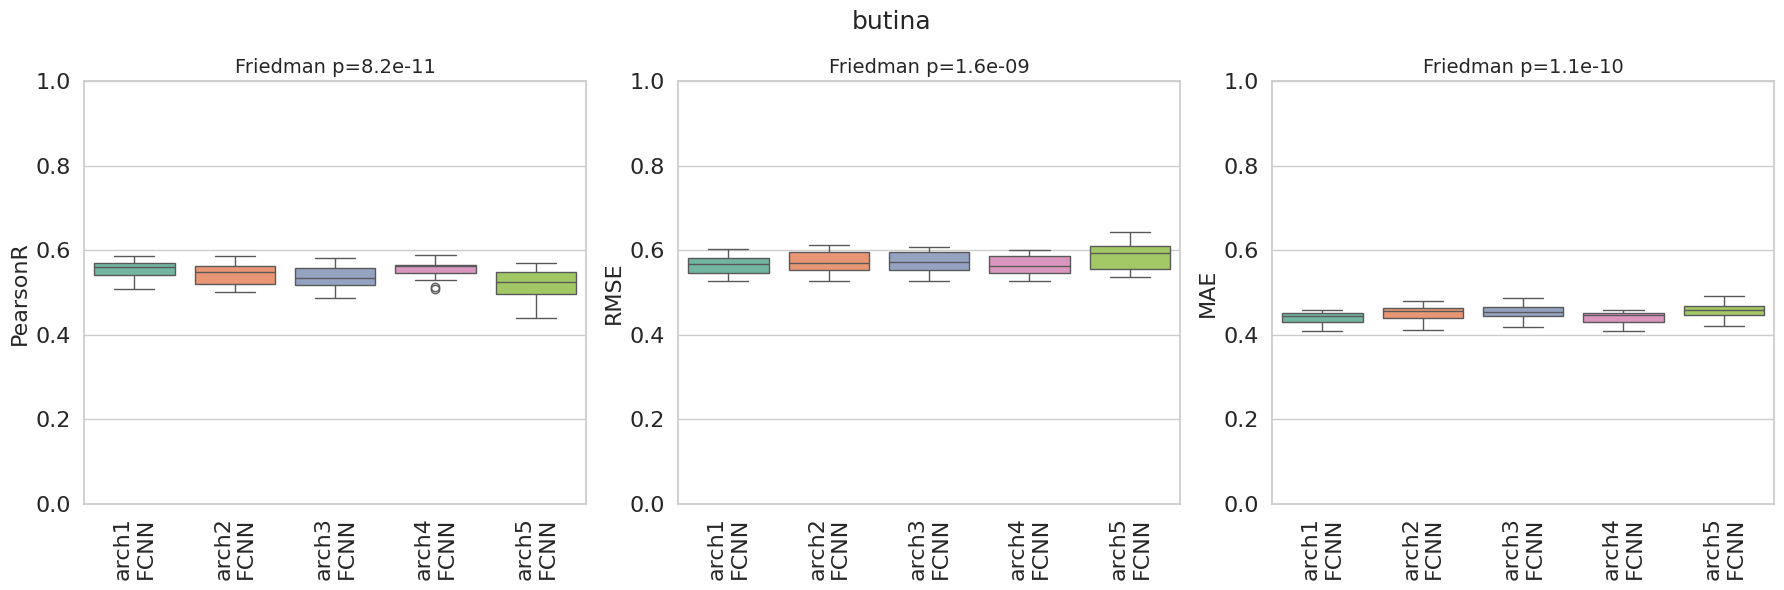

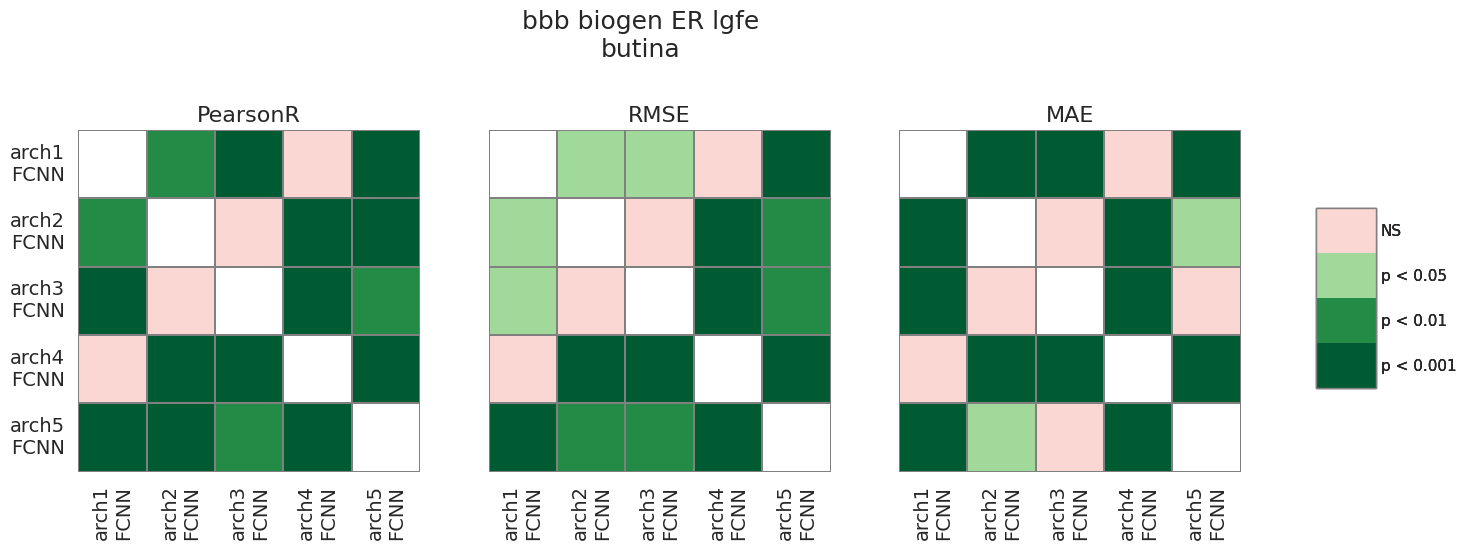

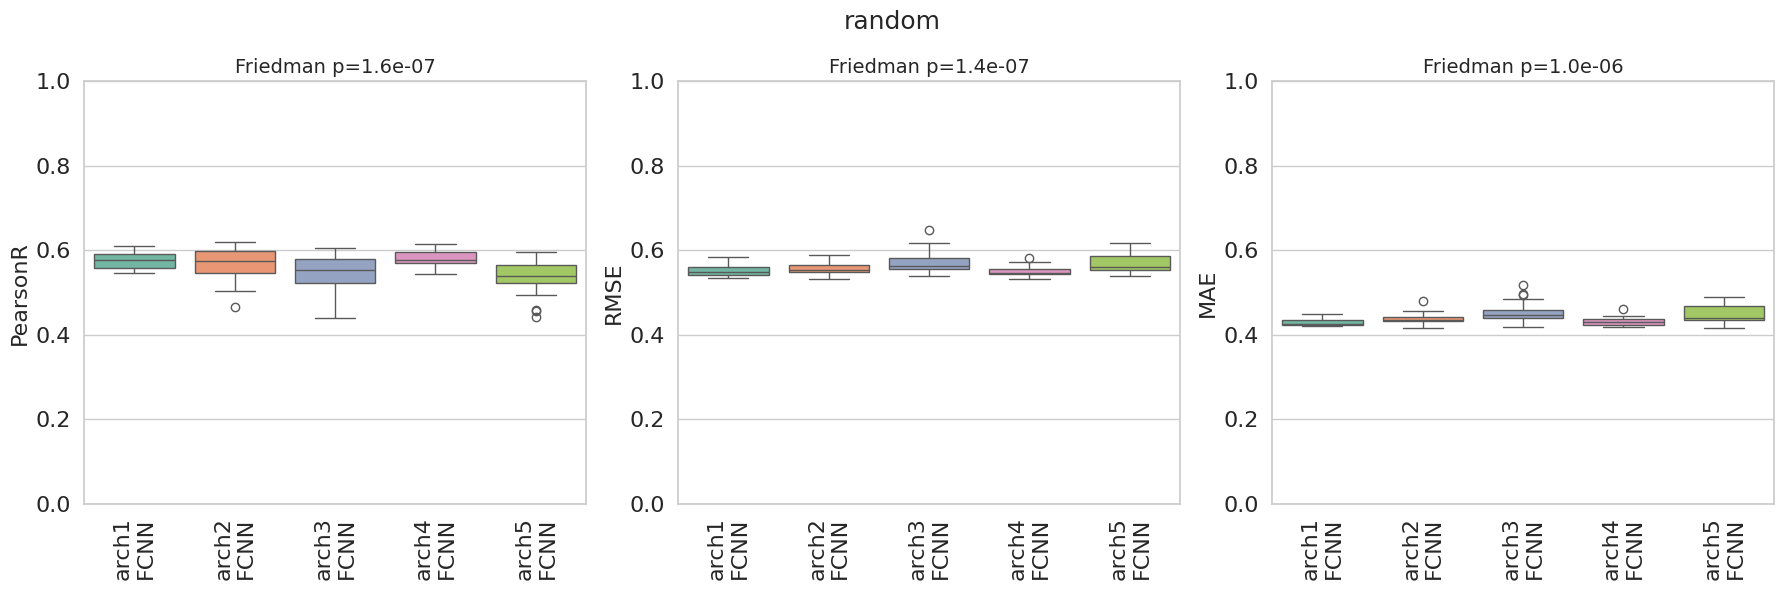

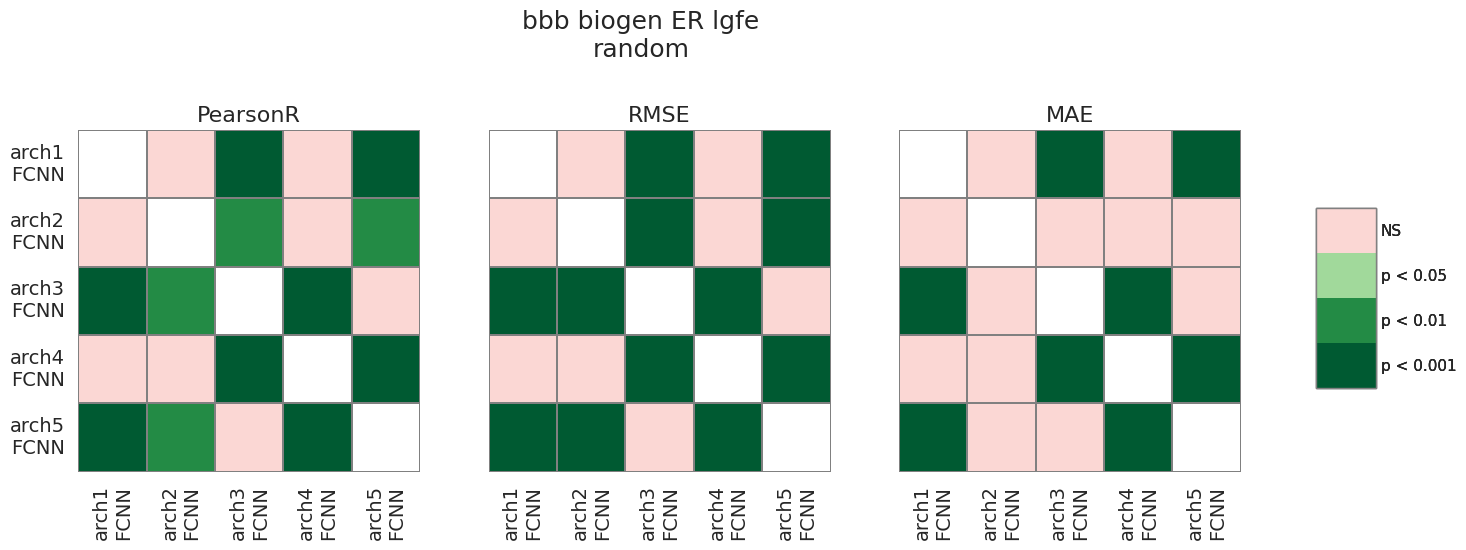

In [3]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/across_fcnn_archs_ER")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/across_fcnn_archs_ER")
        
export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER/across_fcnn_archs_ER/Levene_variance_results.xlsx"
)

#### 1. B. FCNN Arch 1 seems like a good choice for further comparison since it has relatively better performace metrics and lower variablility compared to other architectures tested. 

In [4]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN-1/evaluation_*.csv"]]

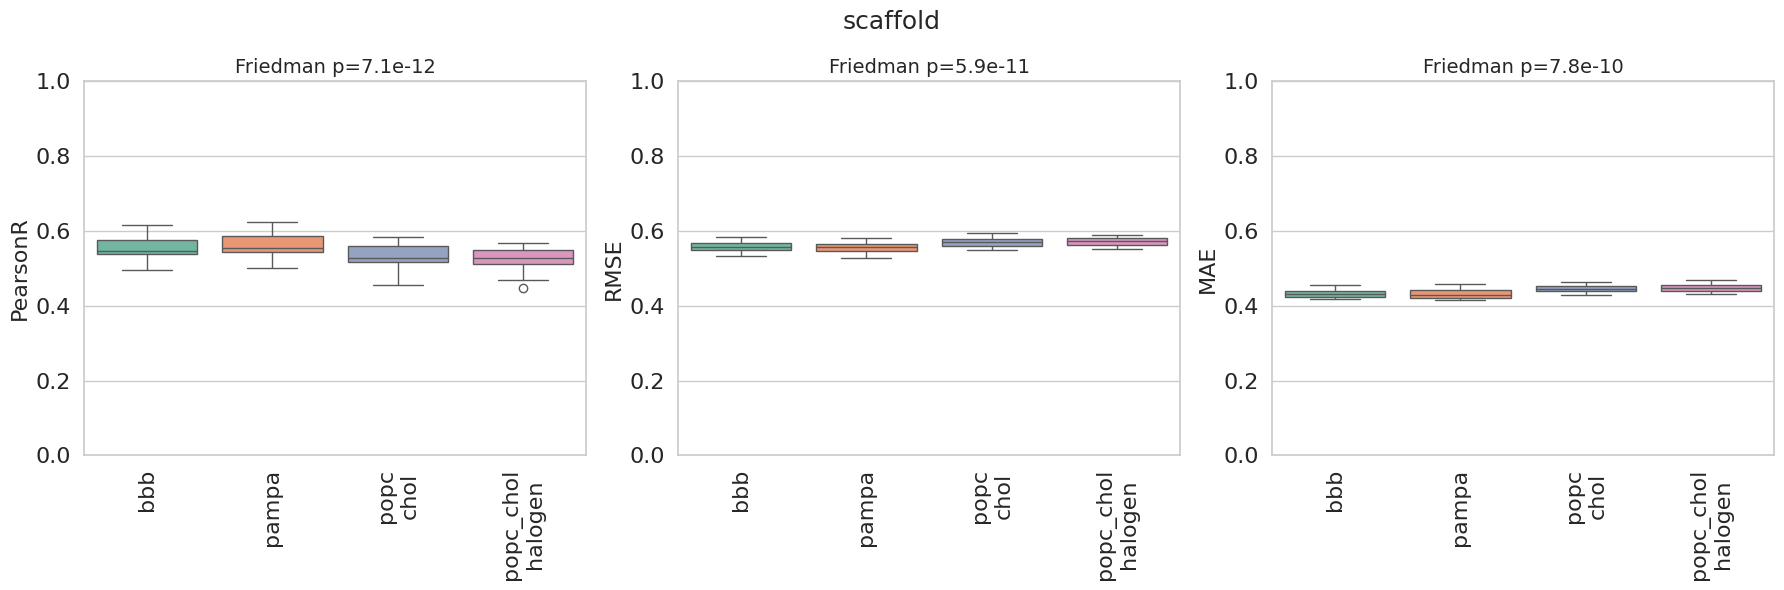

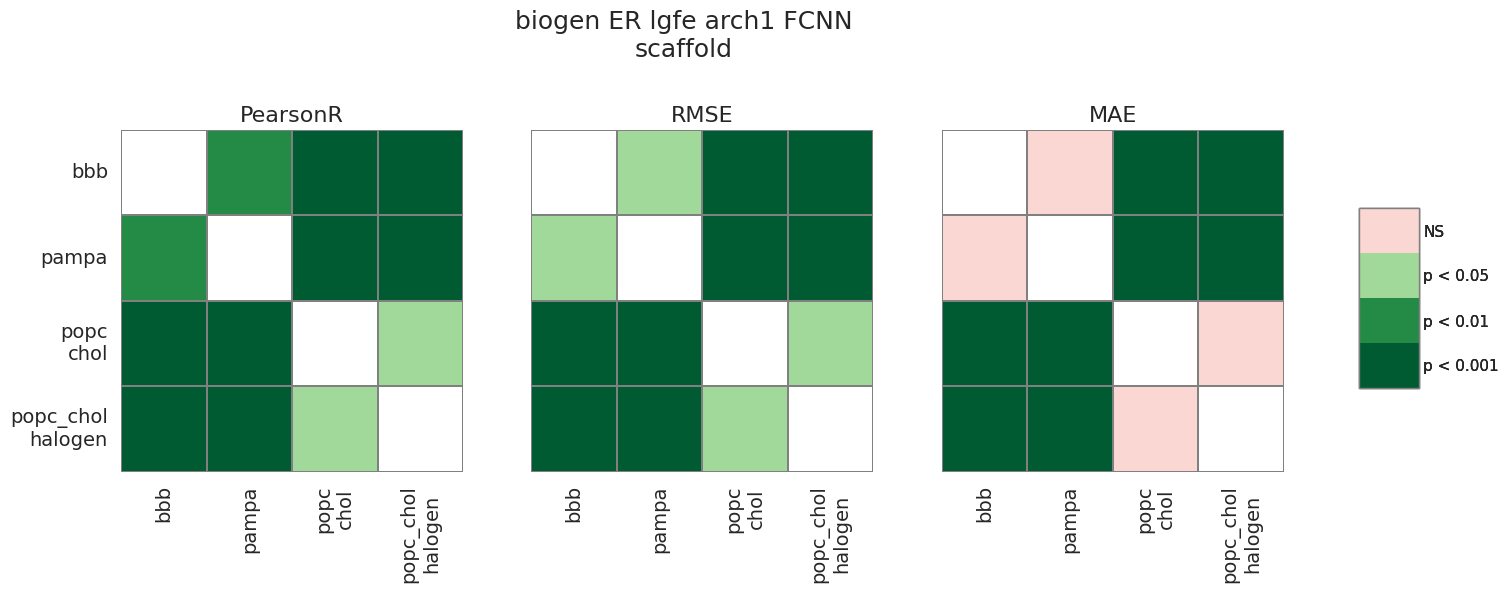

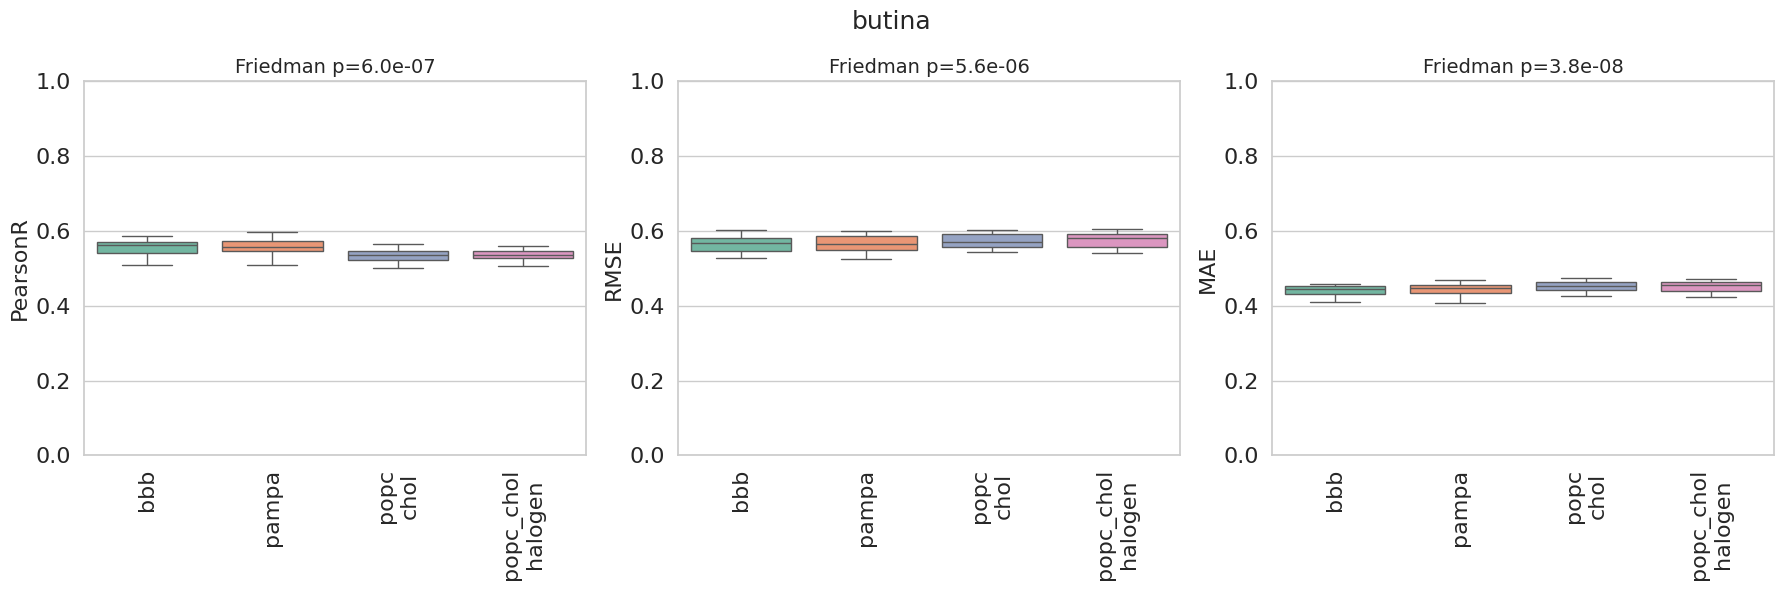

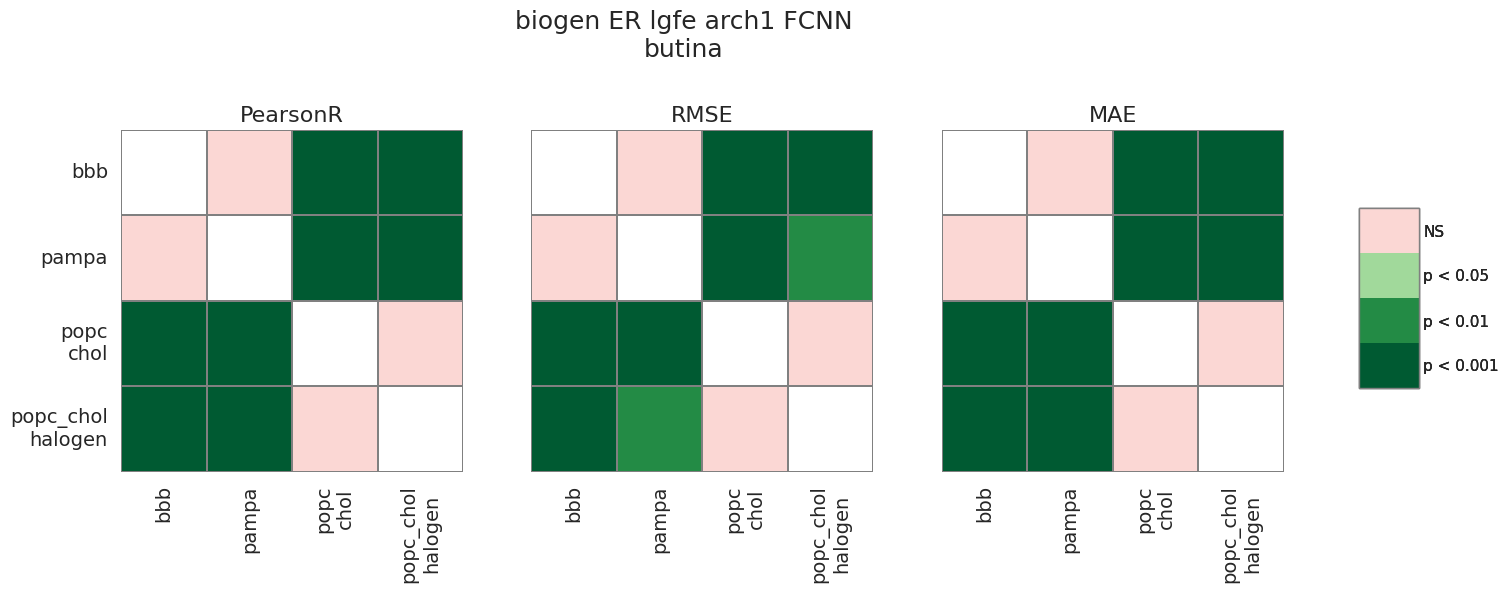

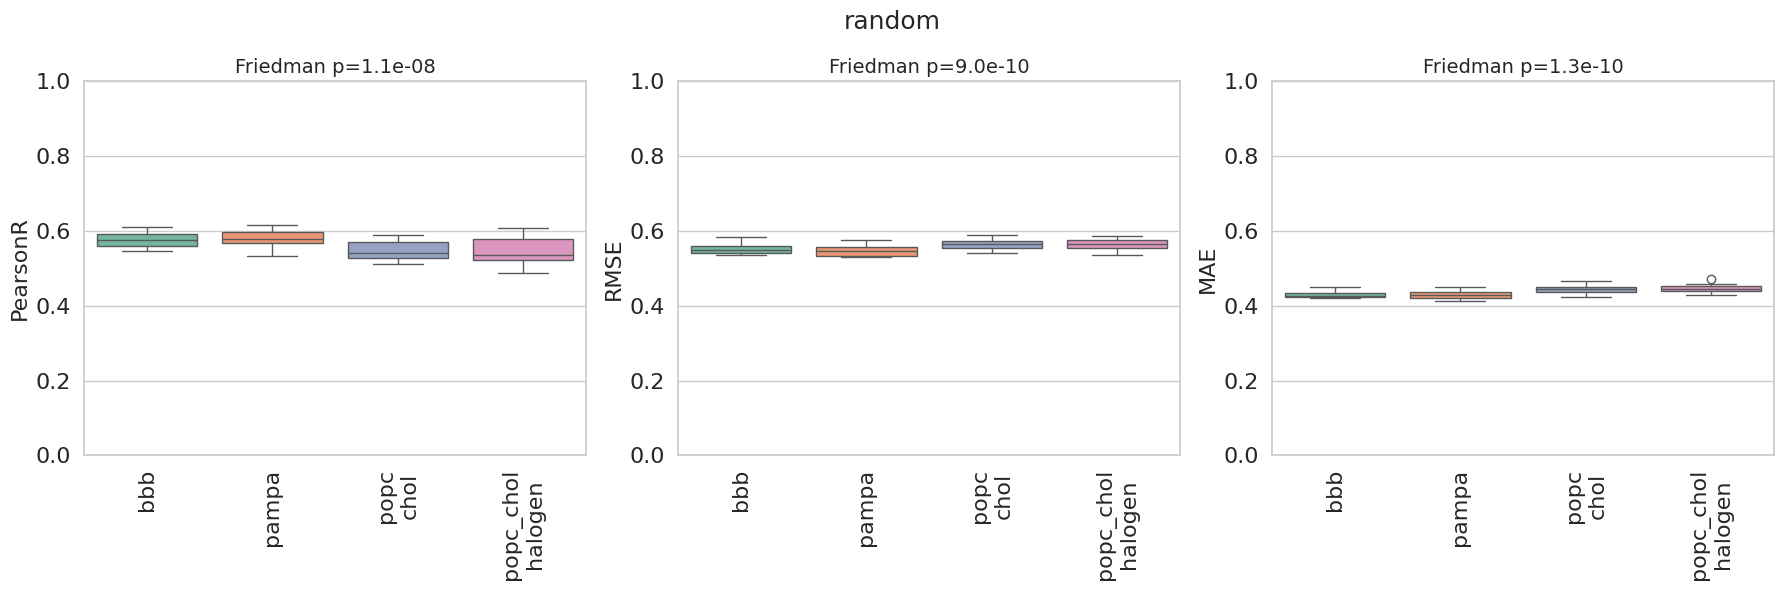

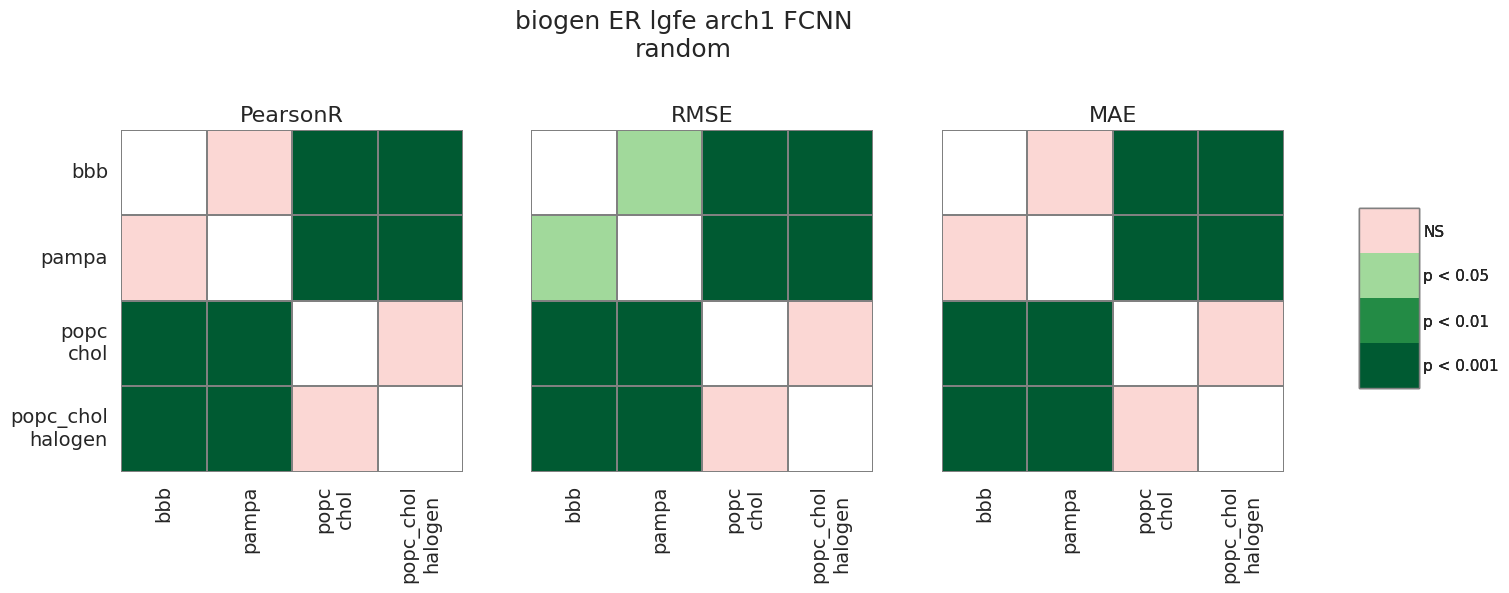

In [7]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/fcnn1_across_membs_ER", common_prefix="-biogen-ER_lgfe_arch1_FCNN")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/fcnn1_across_membs_ER", common_prefix="-biogen-ER_lgfe_arch1_FCNN")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER/fcnn1_across_membs_ER/Levene_variance_results.xlsx"
)

TDLR: Both PAMPA and BBB models are better than simple POPC-CHOL models in terms of FCNN method

### 2. LightGBM

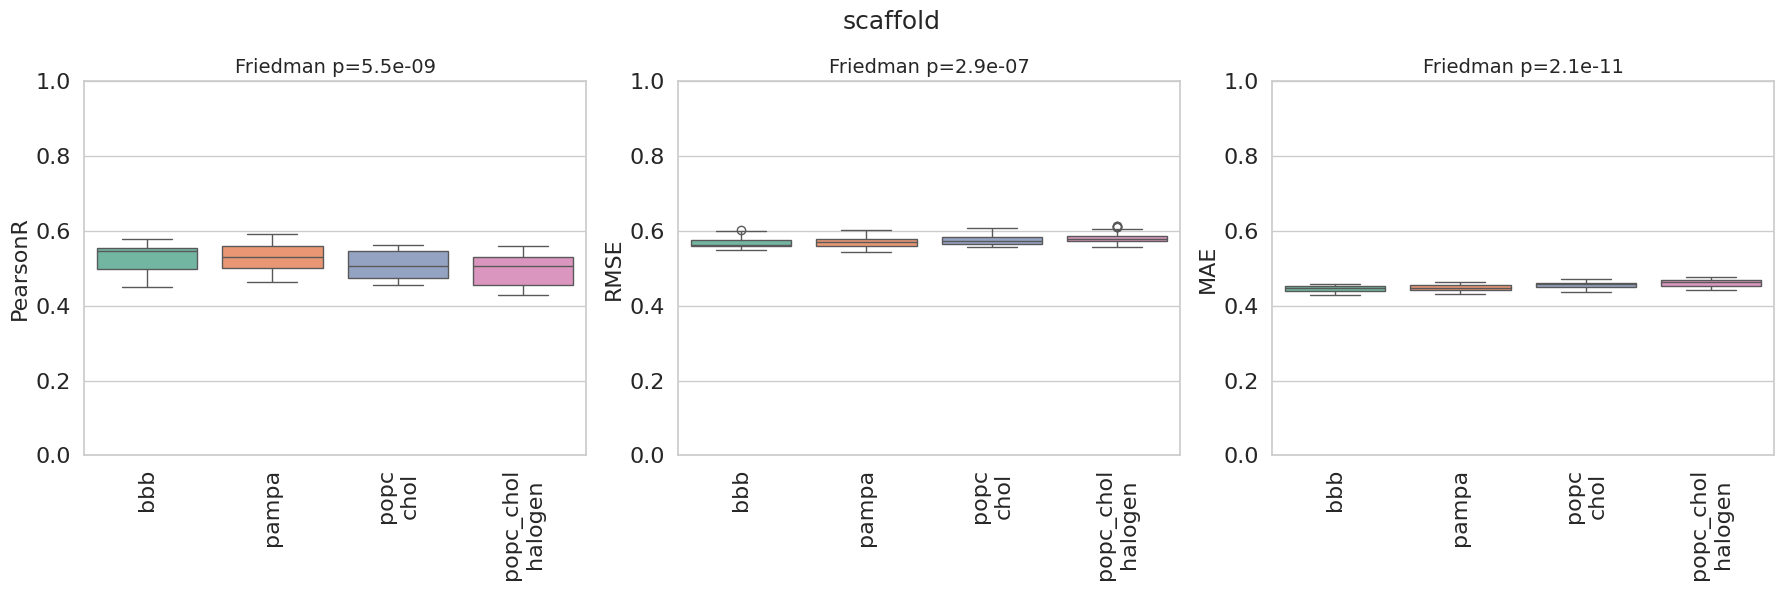

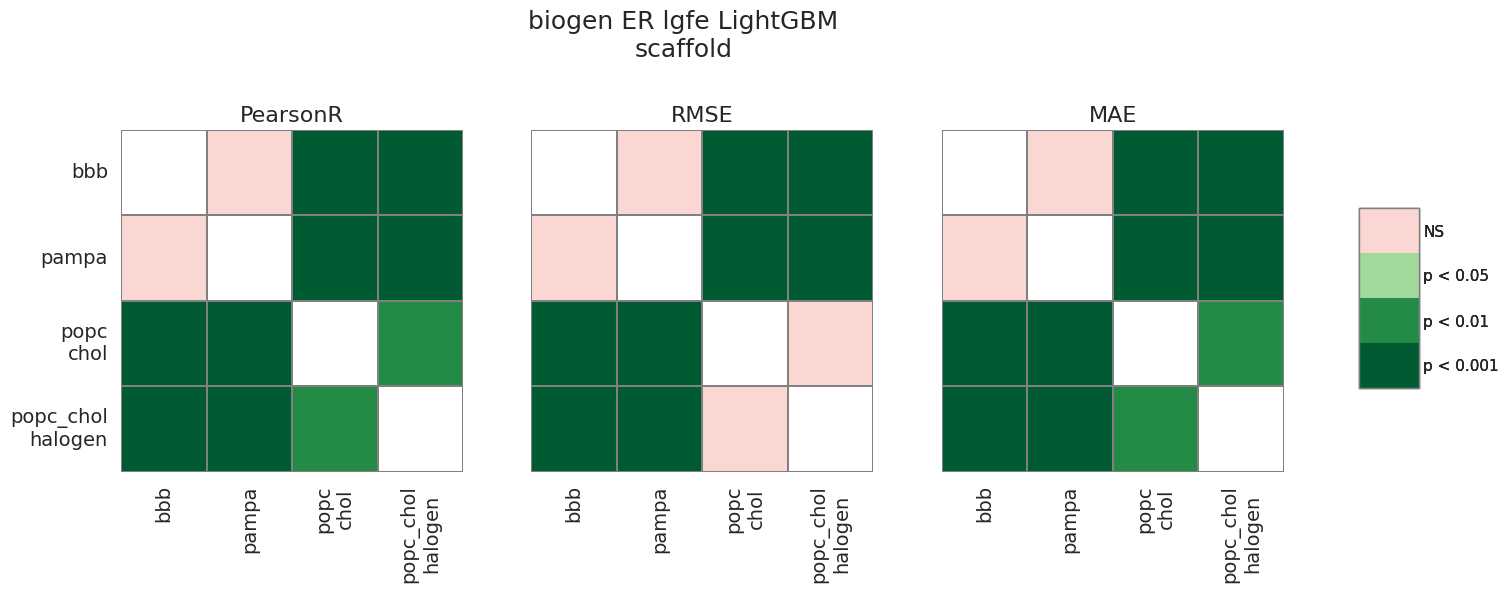

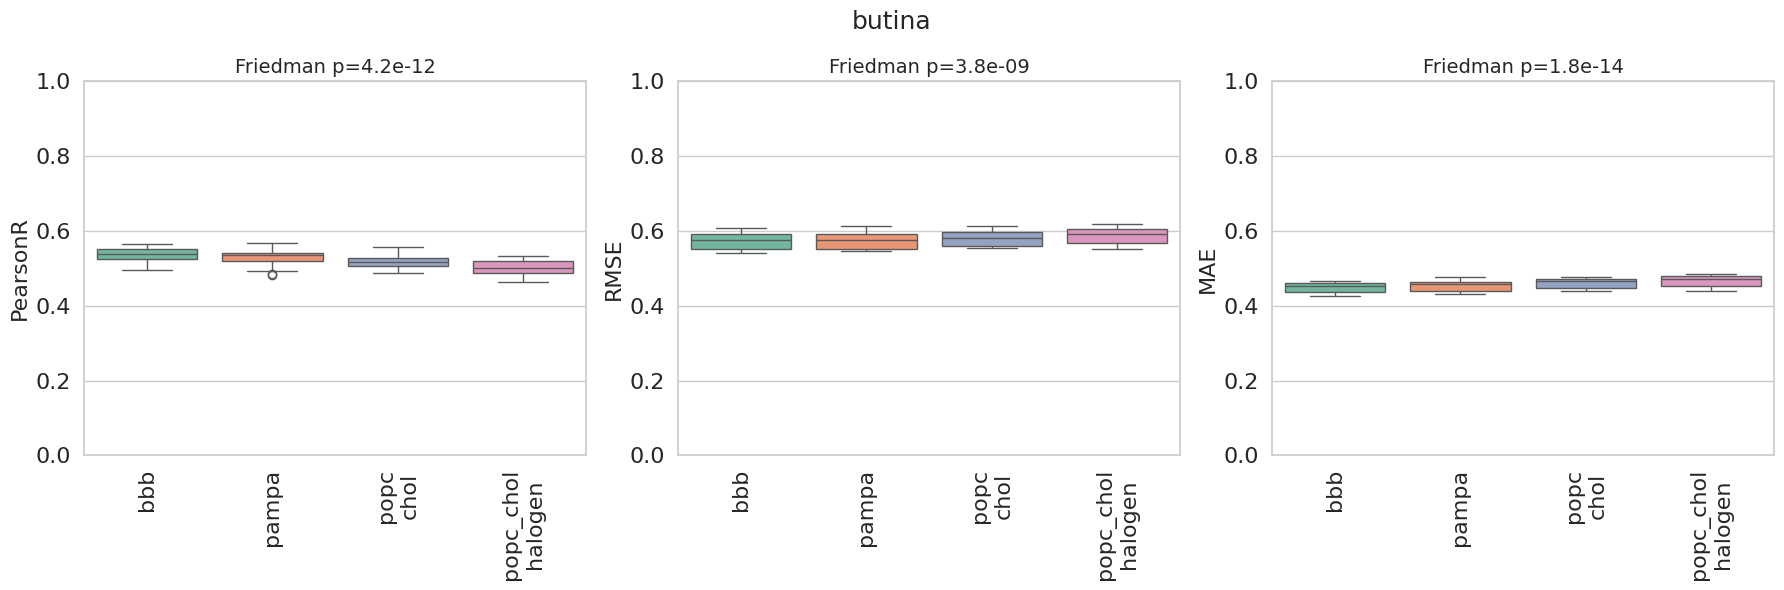

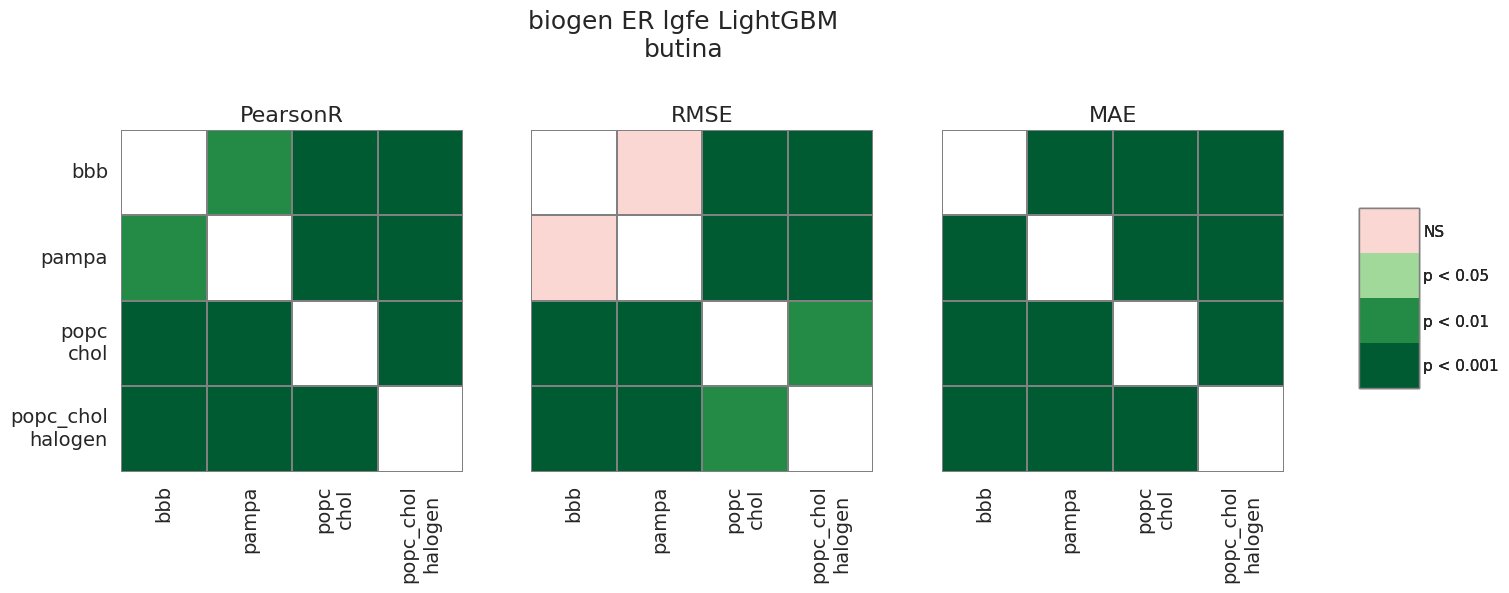

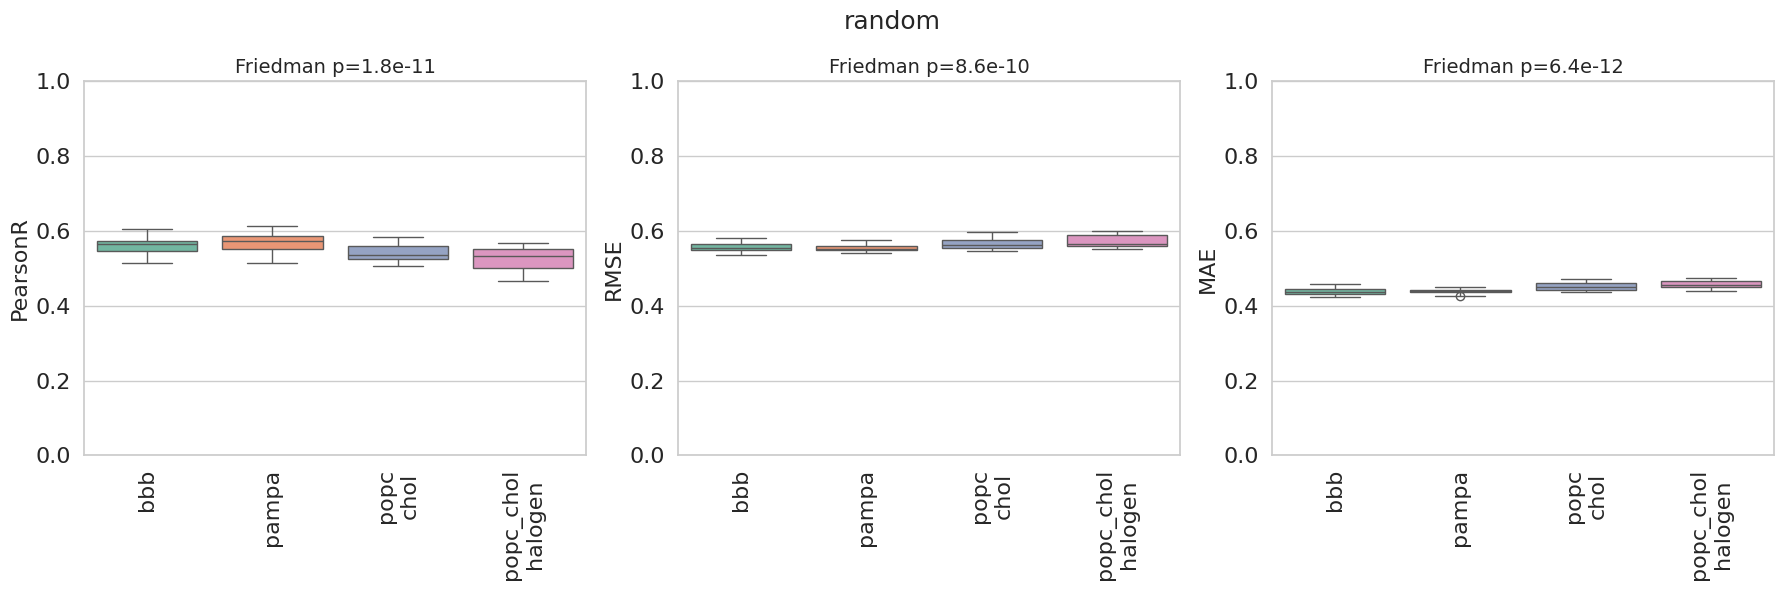

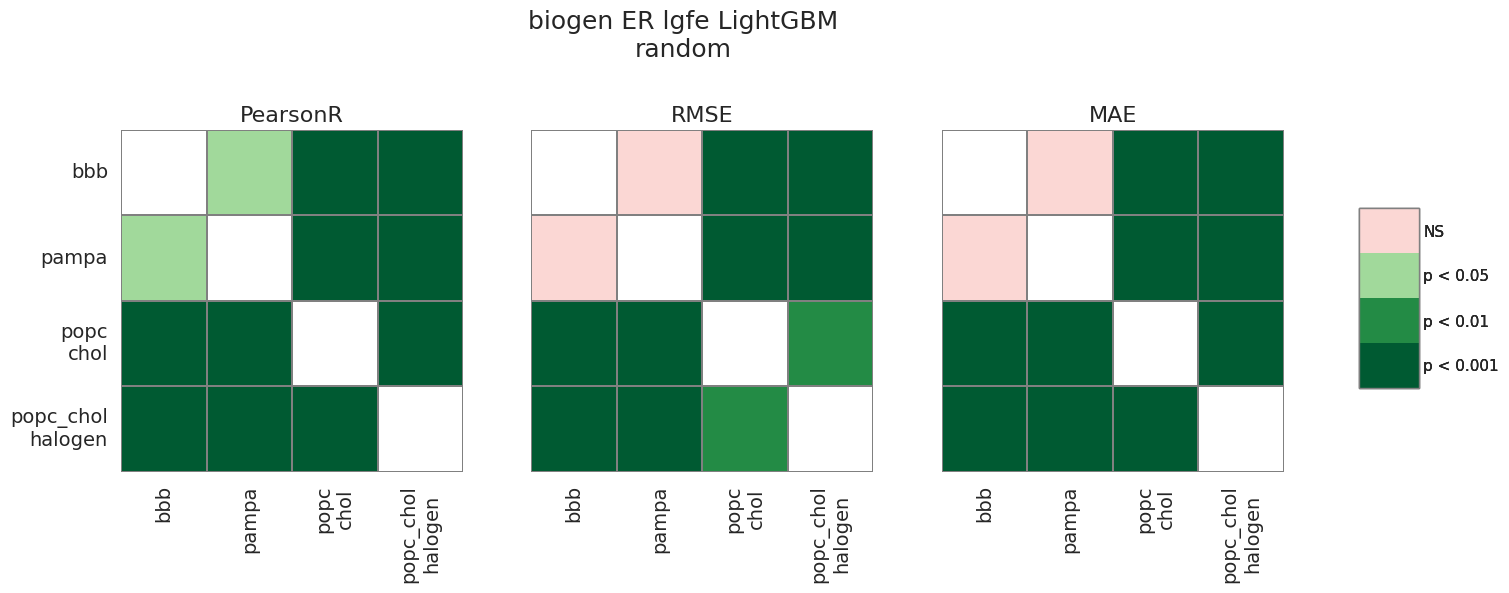

In [8]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_base/evaluation/LightGBM/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/lgbm_across_membs_ER", common_prefix="-biogen-ER_lgfe_LightGBM")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/lgbm_across_membs_ER", common_prefix="-biogen-ER_lgfe_LightGBM")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER/lgbm_across_membs_ER/Levene_variance_results.xlsx"
)

TDLR : Similar to FCNN, BBB and PAMPA models are better than POPC ones. Interestingly depending on the splitting strategy, there is a significant difference in performance between halogen maps and standard maps

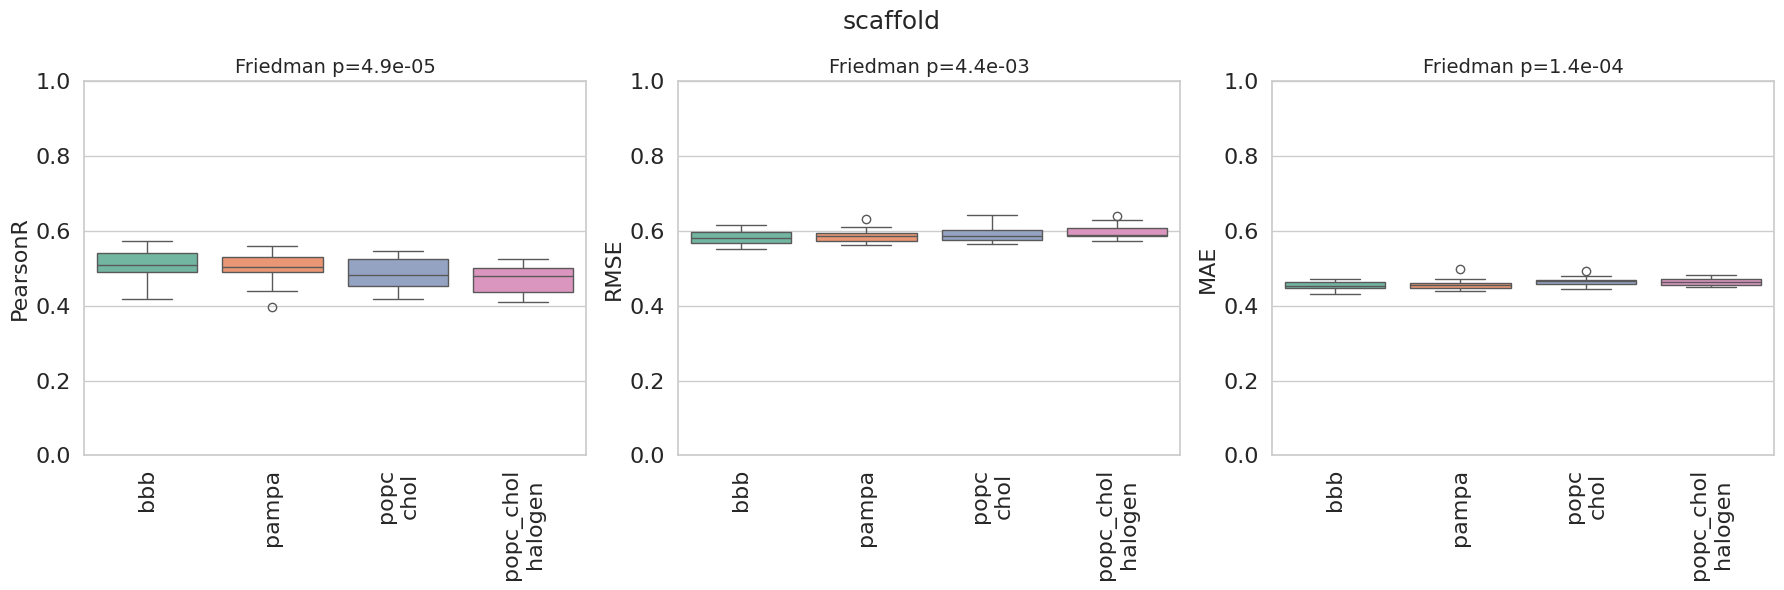

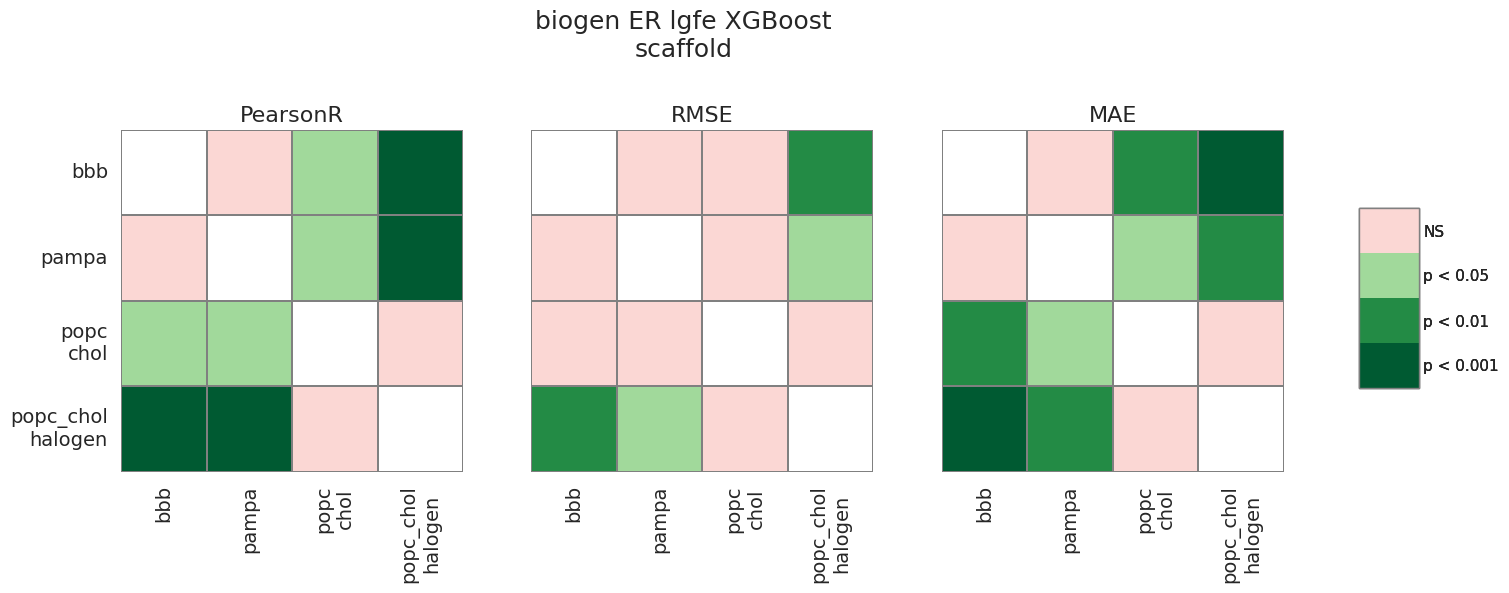

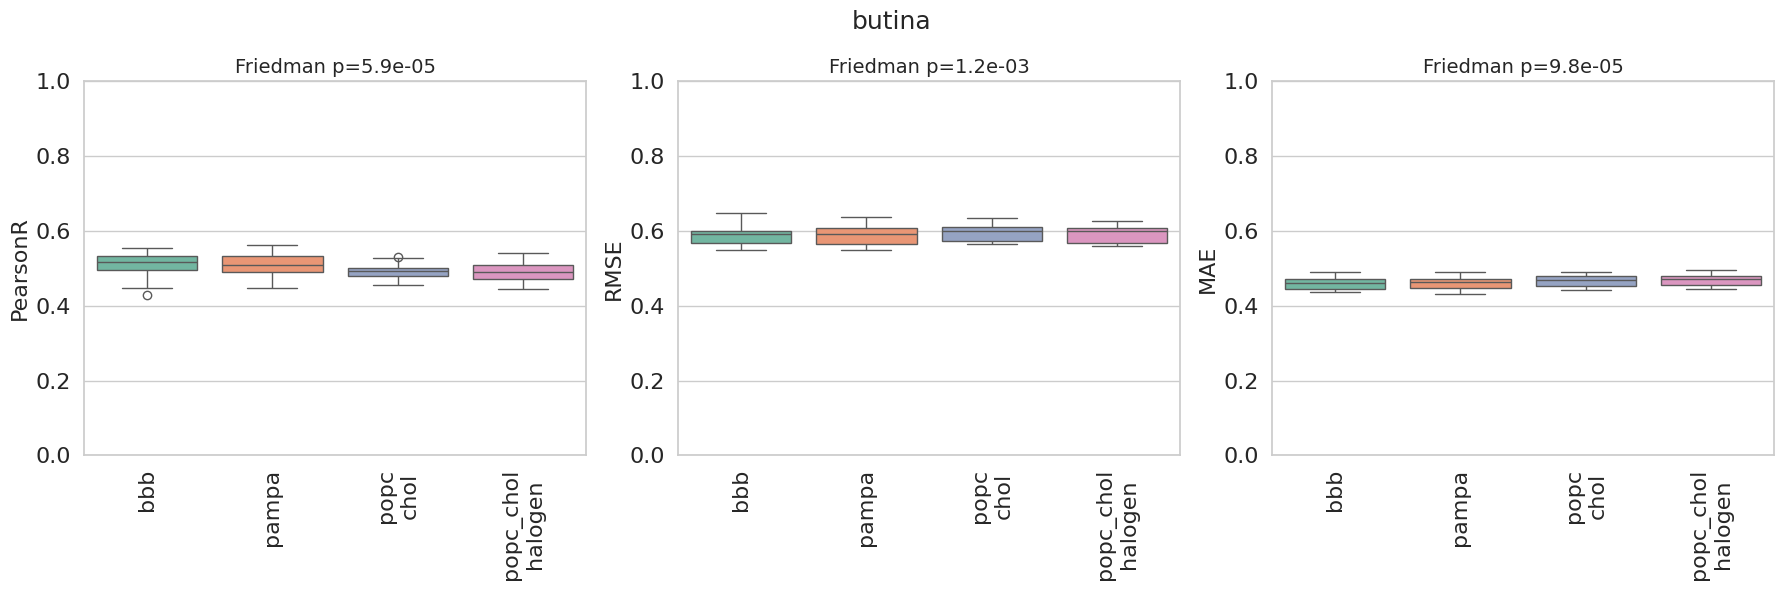

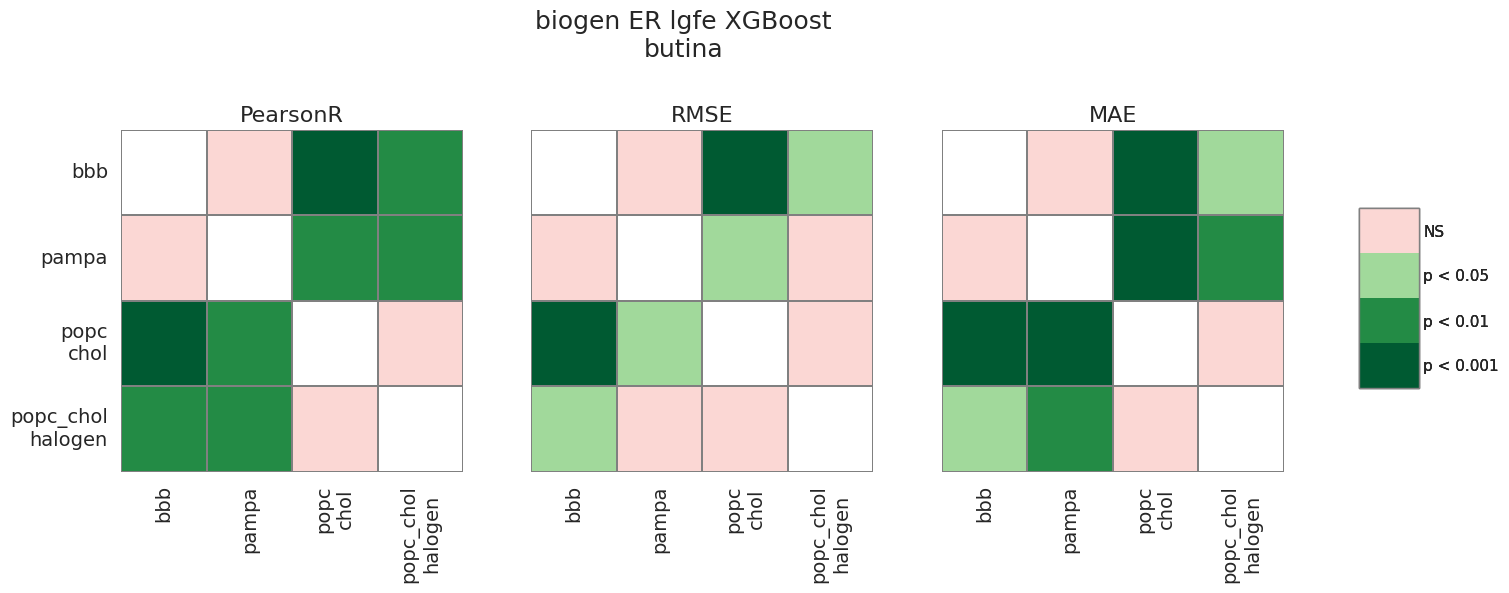

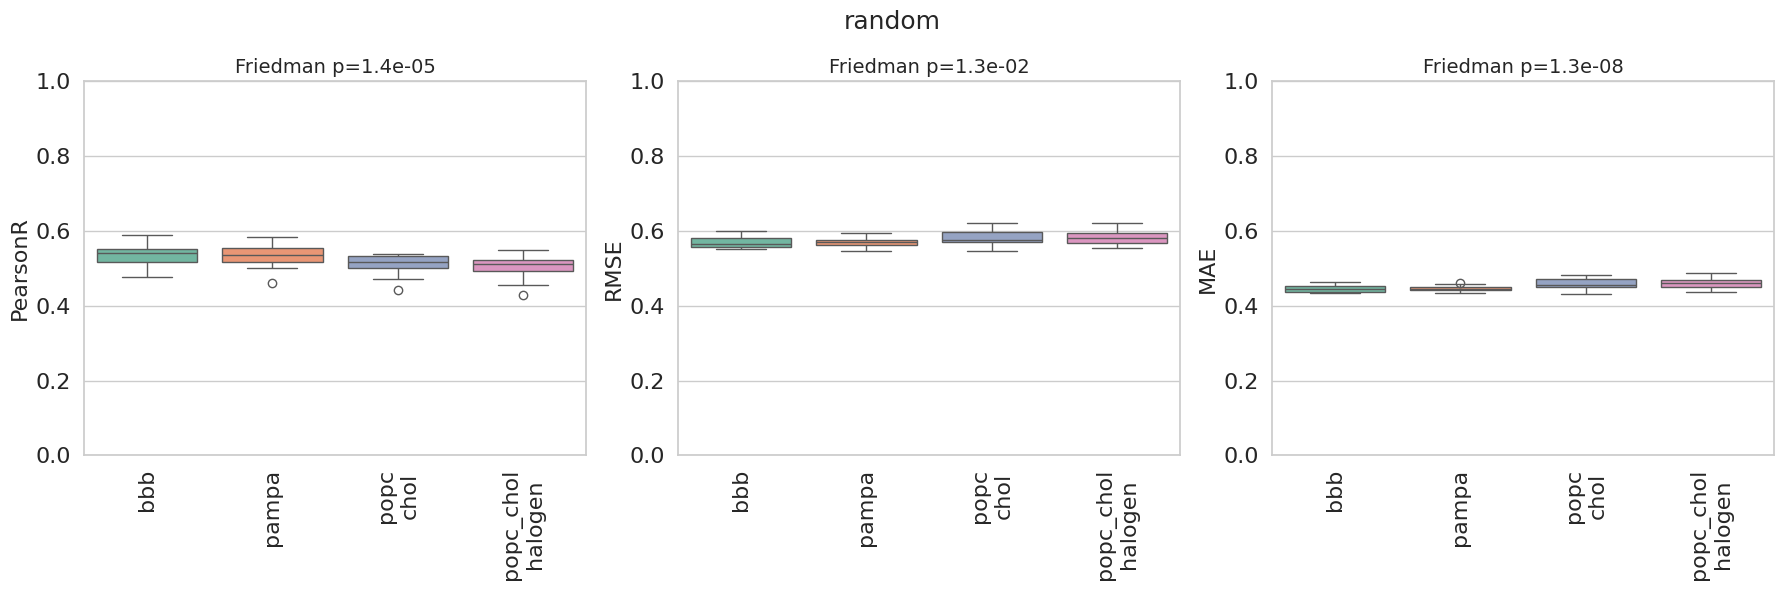

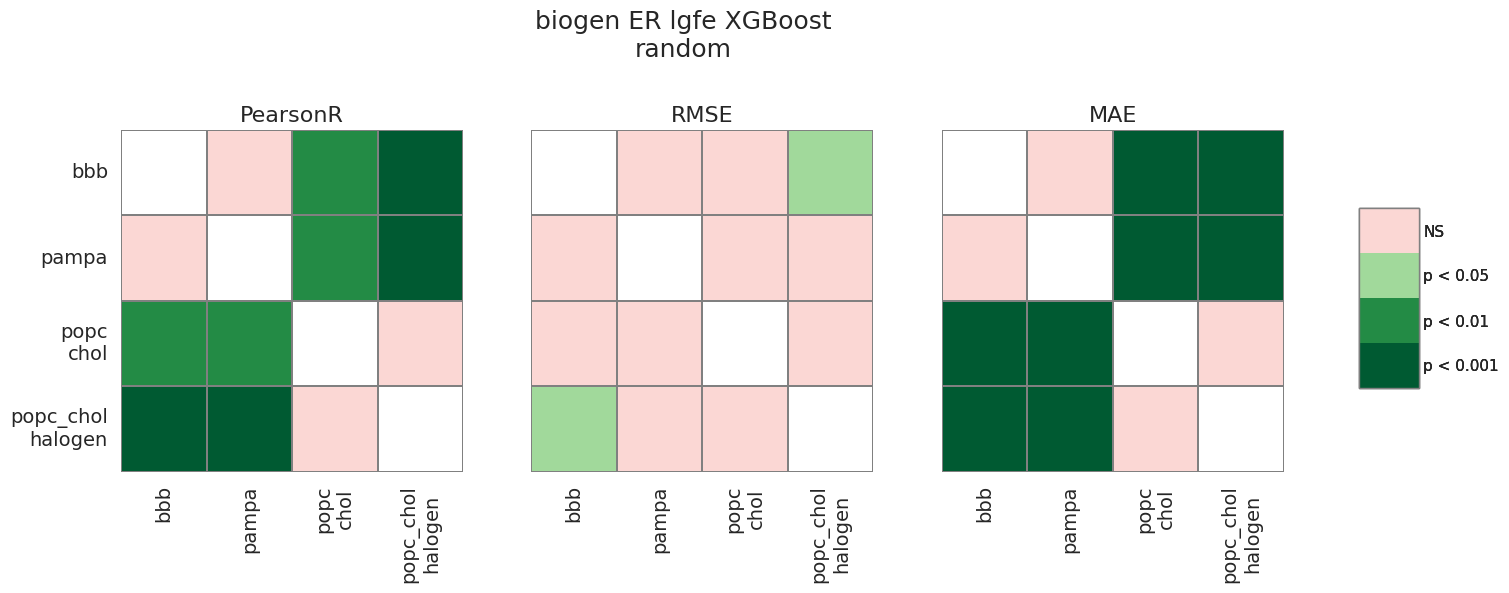

In [9]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_base/evaluation/XGBoost/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/xgb_across_membs_ER", common_prefix="-biogen-ER_lgfe_XGBoost")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/xgb_across_membs_ER", common_prefix="-biogen-ER_lgfe_XGBoost")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER/xgb_across_membs_ER/Levene_variance_results.xlsx"
)

TDLR: Same story : Adding halogen maps does not really improve the performance significantly but often reduce it

### 4. How about FCNN vs ensemble learning models?

evaluation_bbb.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.009956      6.228731
1     butina         RMSE       0.940452      1.805441
2     butina          MAE       0.958761      1.935580
3     butina     PearsonR       0.194516      3.043236
4     butina  SpearmanRho       0.005168      5.568476
5     random           R2       0.036867      4.222477
6     random         RMSE       0.014593      5.350954
7     random          MAE       0.005416      4.209736
8     random     PearsonR       0.709445      2.148464
9     random  SpearmanRho       0.683049      2.948508
10  scaffold           R2       0.668223      2.645647
11  scaffold         RMSE       0.765438      2.585373
12  scaffold          MAE       0.576758      2.154163
13  scaffold     PearsonR       0.918576      1.404294
14  scaffold  SpearmanRho       0.950513      1.880670


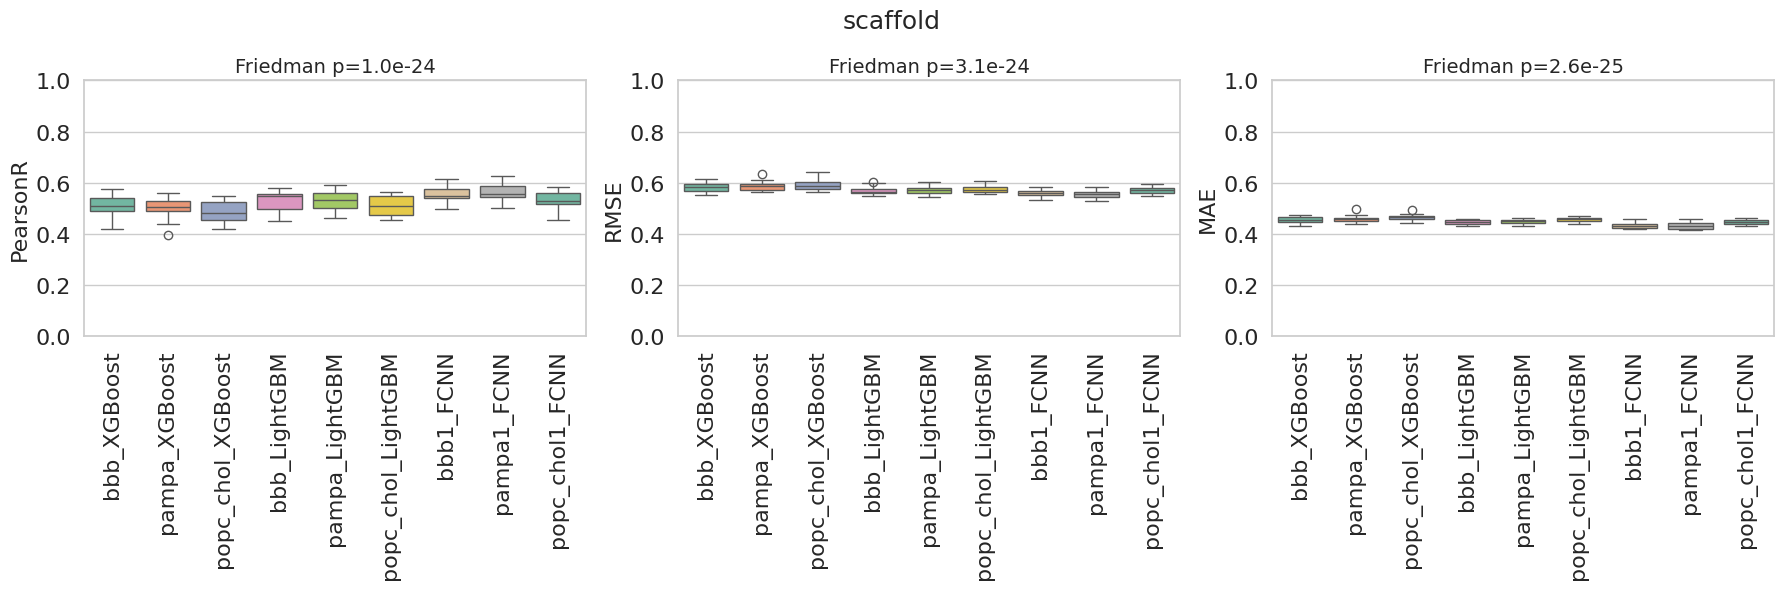

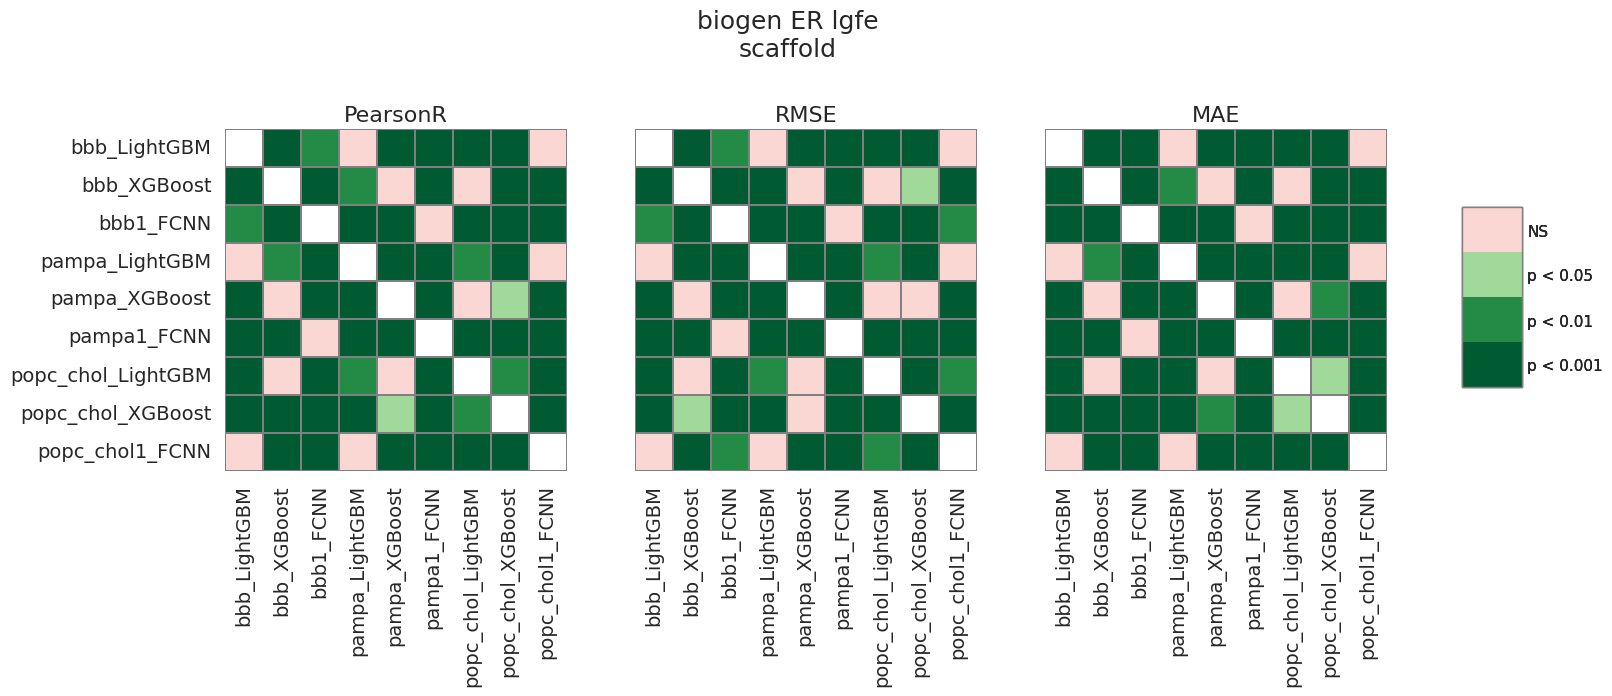

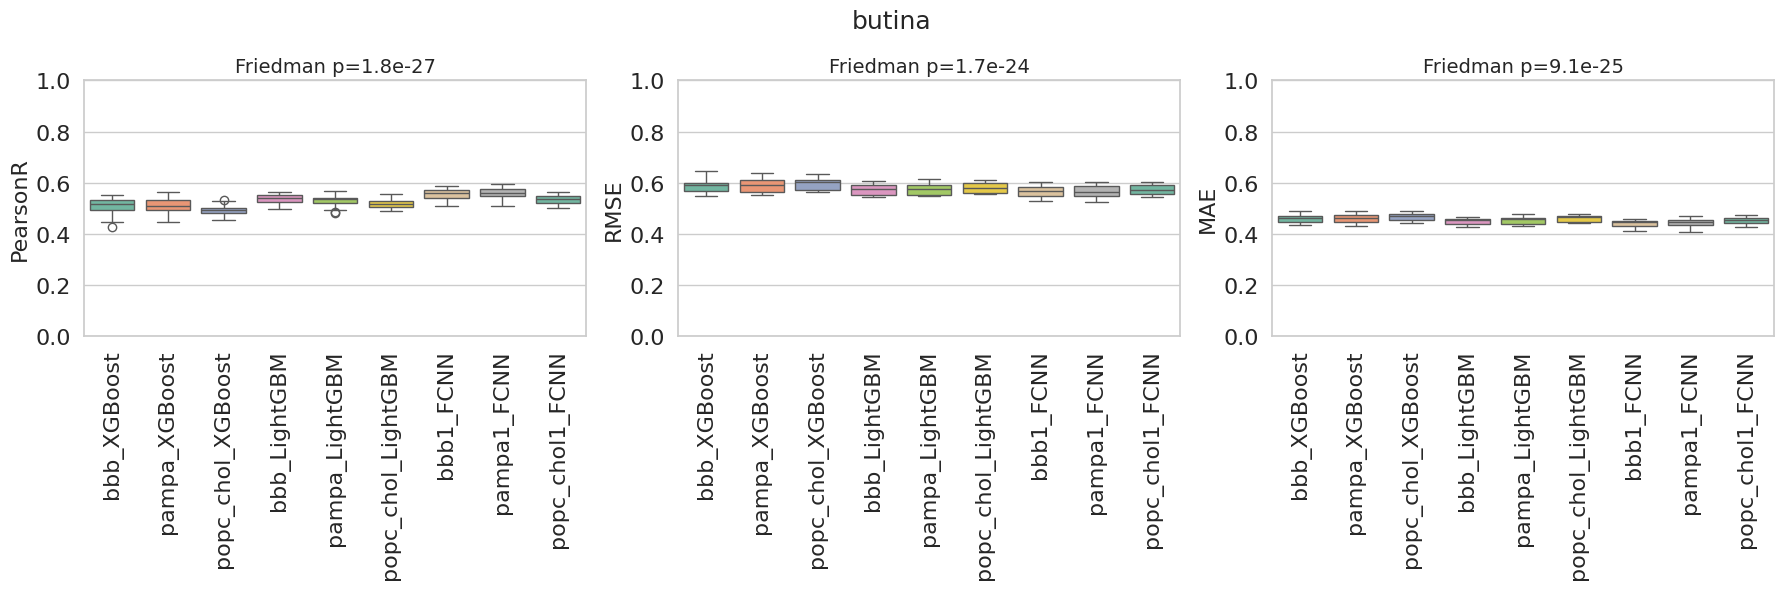

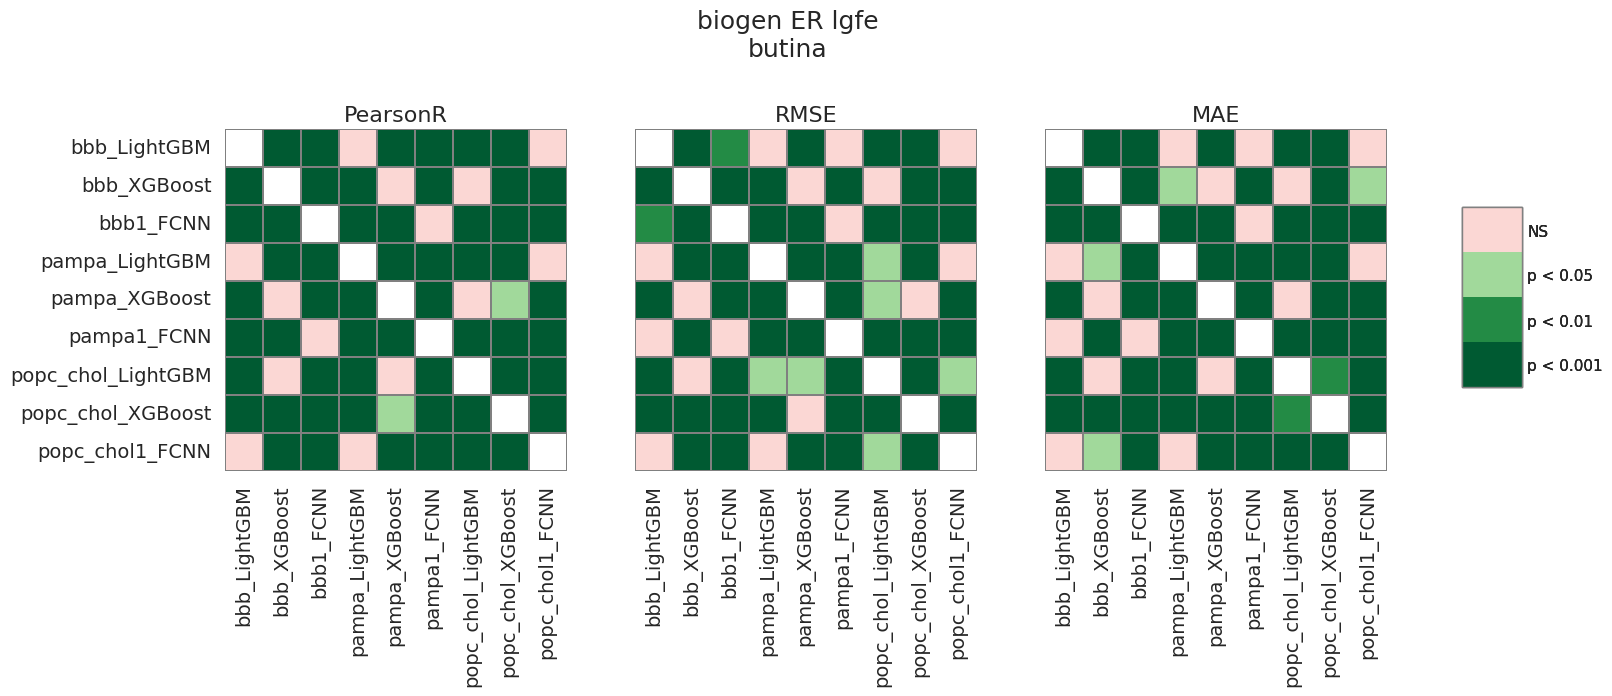

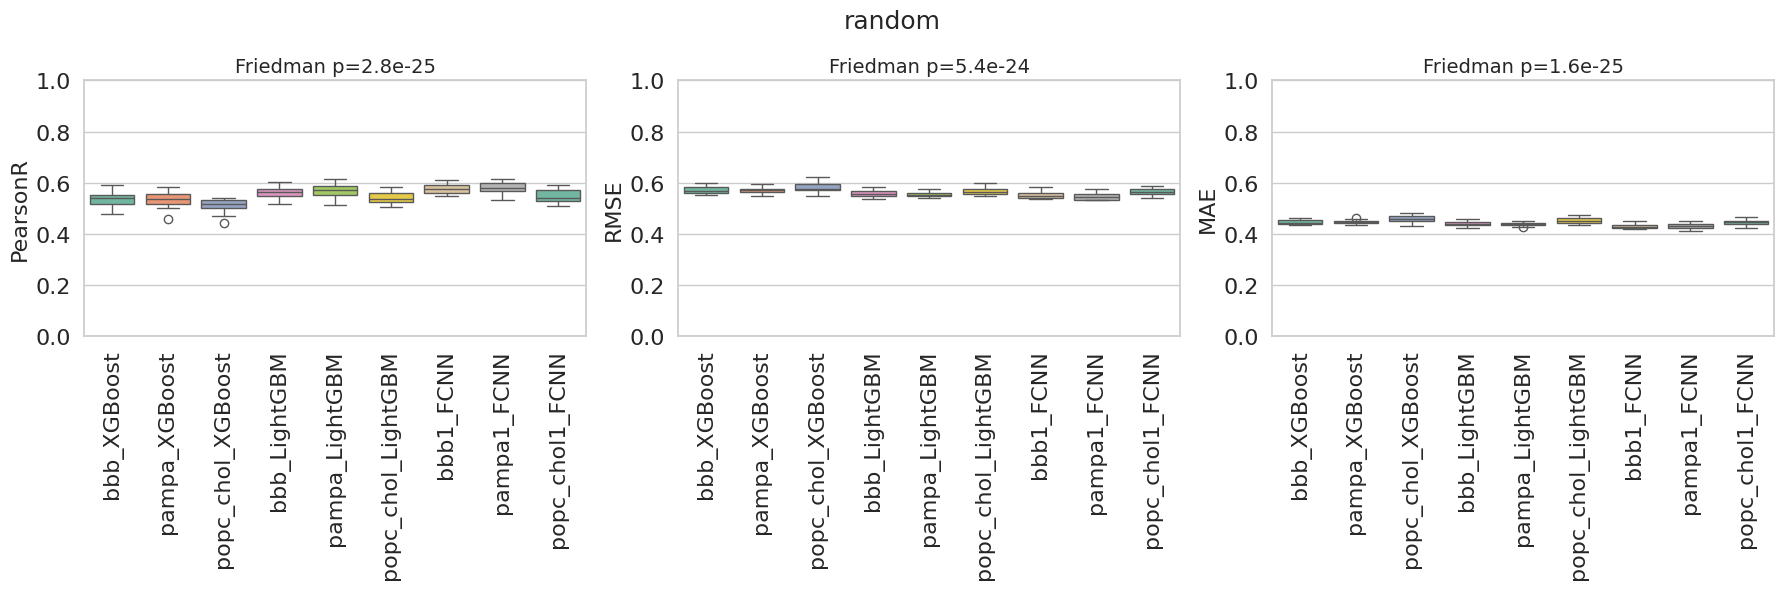

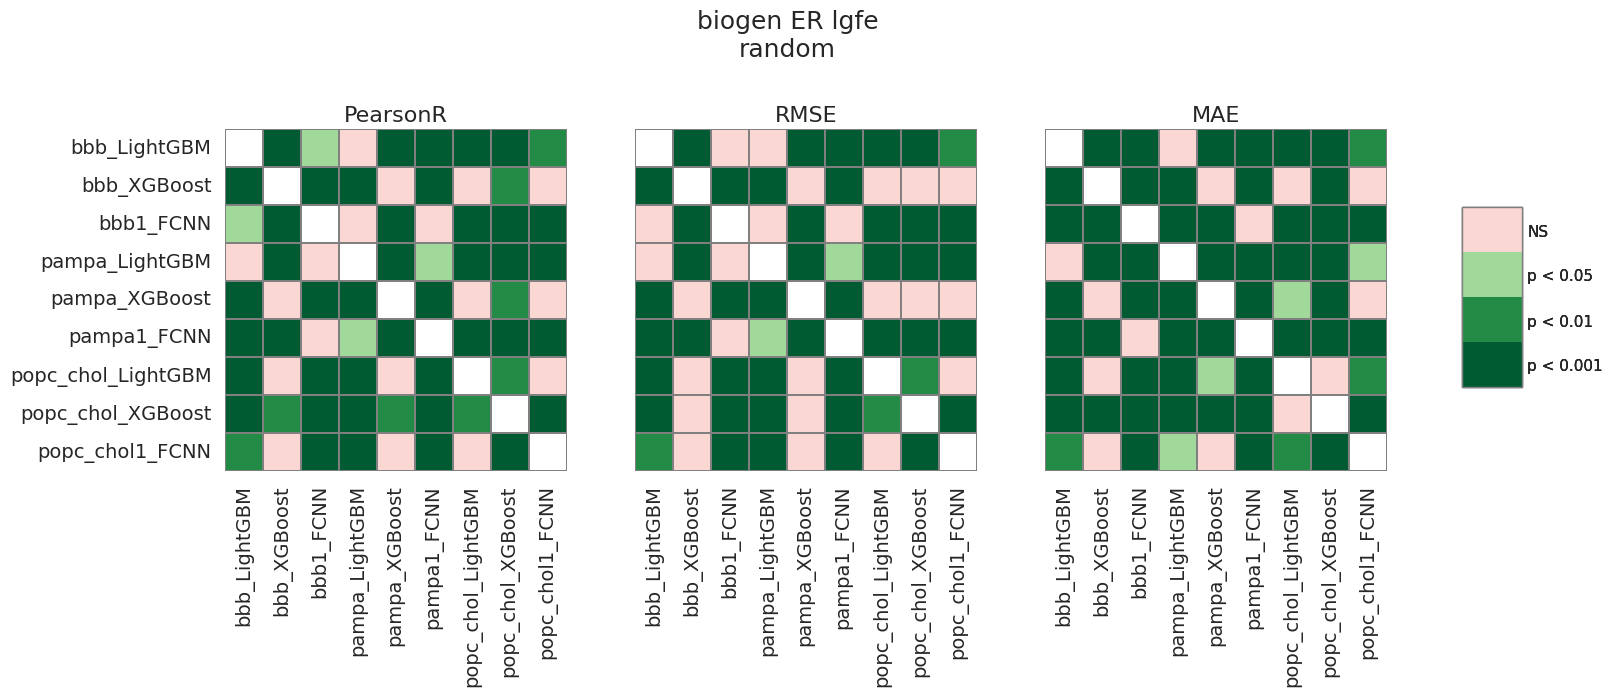

In [10]:
memb_csv_files = [["../ml-modeling-ER_lgfe_biogen_base/evaluation/XGBoost/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/XGBoost/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/XGBoost/evaluation_popc_chol.csv",
                  "../ml-modeling-ER_lgfe_biogen_base/evaluation/LightGBM/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/LightGBM/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/LightGBM/evaluation_popc_chol.csv",
                  "../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN-1/evaluation_bbb.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN-1/evaluation_pampa.csv",
                   "../ml-modeling-ER_lgfe_biogen_base/evaluation/FCNN-1/evaluation_popc_chol.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/allmodels_across_membs_ER", common_prefix="-biogen-ER_lgfe", line_breaks=False)
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_ER/allmodels_across_membs_ER", common_prefix="-biogen-ER_lgfe", line_breaks=False)

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_ER/allmodels_across_membs_ER/Levene_variance_results.xlsx"
)